# Classificador de Criticidade de Bugs — Sistema Híbrido por Stacking

> **Disciplina:** Reconhecimento de Padrões — UPE, 1º Período  
> **Base na literatura:** Lamkanfi et al. (2010) — *Predicting the Severity of a Reported Bug*  
> **Proposta:** Sistema Híbrido via *Stacking* (meta-learning) com TF-IDF + Embeddings LLM

---

## O problema

Dado o **texto** de um relatório de bug ou vulnerabilidade CVE, classificar sua
**criticidade** em três níveis: **Alta**, **Média** ou **Baixa**.

Bug trackers como o Jira do Apache Spark acumulam dezenas de milhares de itens.
Automatizar a triagem economiza horas de revisão manual e prioriza o que realmente
precisa de atenção imediata.

## O que Lamkanfi et al. (2010) fizeram

Treinaram classificadores clássicos (Naive Bayes, SVM, Decision Tree, k-NN) com
representação **bag-of-words** nos projetos Eclipse e Mozilla.

## Nossa extensão

| Dimensão | Lamkanfi (2010) | Este trabalho |
|---|---|---|
| Representação | Bag-of-words | TF-IDF sublinear **+** embeddings Qwen3 |
| Classificador | Modelos independentes | **Stacking** (meta-learning) |
| Datasets | Eclipse, Mozilla | Apache Spark + CIRCL CVE |
| Desbalanceamento | Não tratado | SMOTE dentro do fold de treino |

## Estrutura do notebook

| Seção | Conteúdo |
|---|---|
| 1. Dados | Carregamento Spark e CIRCL, mapeamento de rótulos |
| 2. EDA | Distribuição de classes, comprimento dos textos |
| 3. Pré-processamento | Limpeza de texto, análise de tokens, n-gramas, TF-IDF visual |
| 4. Balanceamento | Undersampling real-first + SMOTE dentro do fold |
| 5. Embeddings | Qwen3-0.6B com cache em disco |
| 6. Framework | Validação cruzada, todas as métricas |
| 7. Baselines | NB, LogReg, SVM (sklearn) + XGBoost, LightGBM (não-sklearn) |
| 8. Seleção | Friedman + Nemenyi pós-hoc |
| 9. Stacking | Sistema híbrido com OOF aninhado |
| 10. Resultados | Tabela consolidada + matrizes de confusão |
| 11. Wilcoxon | Comparação final híbrido vs melhor baseline |
| 12. Conclusão | Síntese e limitações |

## Referências

- Lamkanfi, A. et al. (2010). *Predicting the severity of a reported bug*. MSR 2010.
- Dietterich, T. G. (2000). *Ensemble methods in machine learning*. MCS 2000.
- Kuncheva, L. I. (2014). *Combining Pattern Classifiers*. Wiley.
- Demšar, J. (2006). *Statistical comparisons of classifiers over multiple data sets*. JMLR.

In [1]:
# ── Instalação (descomente se necessário) ─────────────────────────────────────
# !pip install -q imbalanced-learn xgboost lightgbm sentence-transformers
# !pip install -q datasets scikit-posthocs

import warnings, re, string
warnings.filterwarnings('ignore')
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import torch

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef, confusion_matrix
)
from sklearn.utils import resample
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, wilcoxon

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

SEED        = 42
CLASSES     = ['Alta', 'Média', 'Baixa']
CORES       = {'Alta': '#e74c3c', 'Média': '#f39c12', 'Baixa': '#2ecc71'}
N_PER_CLASS = 1_333
N_OUTER     = 10
N_INNER     = 5
EMBED_MODEL = 'qwen3-embedding:0.6b'
DATA_DIR    = Path('../data')
RAW_DIR     = DATA_DIR / 'raw'
RESULTS_DIR = Path('../resultados')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Stopwords simples (inglês) sem dependência de NLTK
STOPWORDS = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','was','are','were','be','been','has','have','had','do','does','did',
    'it','its','this','that','these','those','i','we','you','he','she','they',
    'not','no','so','if','when','where','which','who','will','can','could',
    'should','would','may','might','from','by','as','up','out','about','into',
    'than','then','there','also','just','more','all','any','some','s','t','re',
])

# ── Detecção de GPU ────────────────────────────────────────────────────────────
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
XGB_GPU  = {'tree_method': 'hist', 'device': 'cuda'} if DEVICE == 'cuda' else {}
LGBM_GPU = {'device': 'gpu'} if DEVICE == 'cuda' else {}

print('Ambiente configurado.')
print(f'  SEED={SEED} | N_PER_CLASS={N_PER_CLASS} | N_OUTER={N_OUTER} | N_INNER={N_INNER}')
if DEVICE == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  GPU: {gpu_name}  ({vram_gb:.1f} GB VRAM)')
else:
    print('  GPU: não detectada — rodando em CPU')

Ambiente configurado.
  SEED=42 | N_PER_CLASS=1333 | N_OUTER=10 | N_INNER=5
  GPU: NVIDIA GeForce RTX 3050 Laptop GPU  (4.3 GB VRAM)


---
## Seção 1 — Carregamento de Dados

### Dataset 1: Apache Spark (Jira)

Bugs do rastreador Jira do Apache Spark. Mapeamento de prioridade → criticidade:

| Prioridade Jira | Criticidade |
|---|---|
| Blocker, Critical | Alta |
| Major | Média |
| Minor, Trivial | Baixa |

### Dataset 2: NVD CVE (NIST)

Vulnerabilidades CVE obtidas via NVD REST API 2.0 (NIST). Mapeamento de score CVSS → criticidade (padrão NIST/NVD):

| Score CVSS | Criticidade |
|---|---|
| ≥ 7.0 | Alta |
| 4.0 – 6.9 | Média |
| < 4.0 | Baixa |

In [2]:
PRIORITY_MAP = {
    'Blocker': 'Alta', 'Critical': 'Alta',
    'Major': 'Média',
    'Minor': 'Baixa', 'Trivial': 'Baixa',
}

def clean_text(text, max_chars=1000):
    """Lower-case, colapsa espaços, trunca em max_chars."""
    text = str(text).lower().strip()
    text = ' '.join(text.split())
    return text[:max_chars]

def load_spark(path=None):
    path = path or (RAW_DIR / 'spark_bugs.csv')
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower()
    if 'summary' in df.columns and 'description' in df.columns:
        df['text_raw'] = df['summary'].fillna('') + ' ' + df['description'].fillna('')
    else:
        text_col = next((c for c in ['description','summary','text','body'] if c in df.columns), None)
        df['text_raw'] = df[text_col].fillna('')
    if 'resolution' in df.columns:
        res = df['resolution'].fillna('unknown').str.strip().str.lower()
        df['text_raw'] = 'resolution: ' + res + ' | ' + df['text_raw']
    df['text'] = df['text_raw'].apply(clean_text)
    prio_col = next((c for c in ['priority','Priority','severity'] if c in df.columns), None)
    df['label'] = df[prio_col].map(PRIORITY_MAP)
    df = df.dropna(subset=['label'])
    df = df[df['text'].str.len() > 10]
    return df[['text', 'text_raw', 'label']].reset_index(drop=True)

def map_cvss(score):
    if score >= 7.0: return 'Alta'
    if score >= 4.0: return 'Média'
    return 'Baixa'

def load_circl():
    import requests, time, urllib3
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
    print('Carregando CVEs via NVD API (NIST/NVD)...')
    records = []
    per_page = 2000
    max_fetch = 6000
    start = 0
    total = None
    while (total is None or start < total) and start < max_fetch:
        r = requests.get(
            'https://services.nvd.nist.gov/rest/json/cves/2.0',
            params={'resultsPerPage': per_page, 'startIndex': start},
            timeout=60, verify=False
        )
        r.raise_for_status()
        data = r.json()
        if total is None:
            total = data['totalResults']
            print(f'  Total de CVEs disponíveis: {total}')
        for item in data.get('vulnerabilities', []):
            cve = item['cve']
            desc = next((d['value'] for d in cve.get('descriptions', []) if d['lang'] == 'en'), '')
            score = None
            for key in ['cvssMetricV31', 'cvssMetricV30', 'cvssMetricV2']:
                mlist = cve.get('metrics', {}).get(key, [])
                if mlist:
                    score = mlist[0]['cvssData']['baseScore']
                    break
            cwes = [
                d['value'].lower()
                for w in cve.get('weaknesses', [])
                for d in w.get('description', [])
                if d.get('lang') == 'en' and d.get('value', '').startswith('CWE-')
            ]
            if score is not None and desc:
                records.append({'description': desc, 'cvss': float(score), 'cwe': ' '.join(cwes)})
        start += per_page
        print(f'  Obtidos {len(records)} registros com score...')
        if start < min(total or 0, max_fetch):
            time.sleep(6)
    df = pd.DataFrame(records)
    df['text_raw'] = df.apply(
        lambda r: ('cwe: ' + r['cwe'] + ' | ' + r['description']) if r.get('cwe') else r['description'],
        axis=1
    ).fillna('')
    df['text'] = df['text_raw'].apply(clean_text)
    df['cvss'] = pd.to_numeric(df['cvss'], errors='coerce')
    df = df.dropna(subset=['cvss'])
    df = df[(df['cvss'] >= 0) & (df['cvss'] <= 10)]
    df = df[df['text'].str.len() > 10]
    df['label'] = df['cvss'].apply(map_cvss)
    print(f'  Dataset: {len(df)} entradas | {df["label"].value_counts().to_dict()}')
    return df[['text', 'text_raw', 'label']].reset_index(drop=True)
df_spark_full = load_spark()
df_circl_full = load_circl()

def show_info(df, nome):
    print()
    print(f'=== {nome} ===')
    counts = df['label'].value_counts().reindex(CLASSES)
    pct    = (counts / counts.sum() * 100).round(1)
    print(pd.DataFrame({'Contagem': counts, 'Percentual (%)': pct}).to_string())

show_info(df_spark_full, 'Apache Spark')
show_info(df_circl_full, 'CIRCL CVE')


Carregando CVEs via NVD API (NIST/NVD)...
  Total de CVEs disponíveis: 358218
  Obtidos 1966 registros com score...
  Obtidos 3963 registros com score...
  Obtidos 5955 registros com score...
  Dataset: 5955 entradas | {'Alta': 2933, 'Média': 2474, 'Baixa': 548}

=== Apache Spark ===
       Contagem  Percentual (%)
label                          
Alta        463             2.3
Média     15148            74.7
Baixa      4664            23.0

=== CIRCL CVE ===
       Contagem  Percentual (%)
label                          
Alta       2933            49.3
Média      2474            41.5
Baixa       548             9.2


---
## Seção 2 — Análise Exploratória (EDA)

Antes de qualquer modelagem, entendemos a distribuição dos dados:

- **Distribuição de classes** — verificar o desbalanceamento
- **Comprimento dos textos** — entender a variabilidade

O desbalanceamento é o problema central: a classe **Alta** representa ~2% dos bugs
do Spark. Um modelo que sempre prevê "Média" teria ~75% de acurácia mas seria
inútil — por isso usamos **F1-macro** como métrica principal.

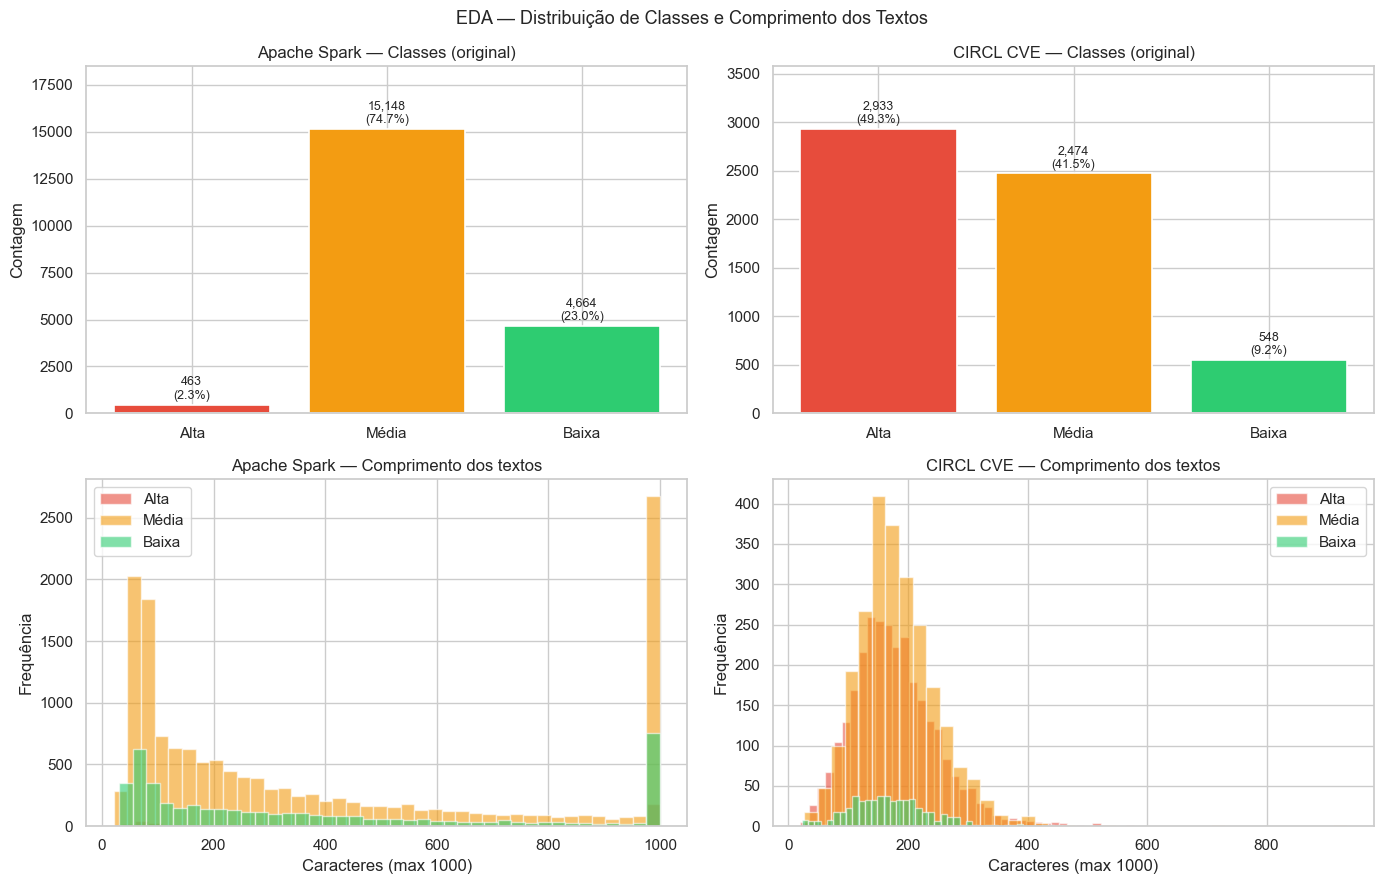


Comprimento dos textos (após limpeza):
  Spark: min=21 | mediana=248 | média=396 | max=1000
  CIRCL: min=20 | mediana=171 | média=179 | max=934


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('EDA — Distribuição de Classes e Comprimento dos Textos', fontsize=13)

for col, (df, nome) in enumerate([(df_spark_full, 'Apache Spark'), (df_circl_full, 'CIRCL CVE')]):
    # Distribuição de classes
    ax = axes[0, col]
    counts = df['label'].value_counts().reindex(CLASSES)
    bars = ax.bar(CLASSES, counts, color=[CORES[c] for c in CLASSES], edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{nome} — Classes (original)')
    ax.set_ylabel('Contagem'); ax.set_ylim(0, counts.max() * 1.22)

    # Comprimento dos textos por classe
    ax = axes[1, col]
    for cls in CLASSES:
        lens = df[df['label'] == cls]['text'].str.len().clip(upper=1000)
        ax.hist(lens, bins=40, alpha=0.6, label=cls, color=CORES[cls])
    ax.set_title(f'{nome} — Comprimento dos textos')
    ax.set_xlabel('Caracteres (max 1000)'); ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Estatísticas descritivas de comprimento
print('\nComprimento dos textos (após limpeza):')
for df, nome in [(df_spark_full, 'Spark'), (df_circl_full, 'CIRCL')]:
    s = df['text'].str.len()
    print(f'  {nome}: min={s.min()} | mediana={s.median():.0f} | média={s.mean():.0f} | max={s.max()}')

---
## Seção 3 — Pré-processamento de Texto

### O que fazemos (e o que não fazemos)

Nosso pré-processamento é **intencionalmente mínimo**:

| Etapa | Fazemos? | Justificativa |
|---|---|---|
| Lower-case | ✅ | Normaliza maiúsculas sem perda semântica |
| Colapsar espaços | ✅ | Remove ruído de formatação |
| Truncar em 1000 chars | ✅ | Limita custo de embedding sem perder info |
| Remover stopwords | ❌ | O TF-IDF já penaliza via IDF; embeddings precisam do contexto |
| Stemming/Lemmatização | ❌ | Causa perda semântica para embeddings |
| Remover pontuação | ❌ | Pontuação carrega informação (ex: `NullPointerException`) |

### Análises desta seção

1. **Efeito do truncamento** — quanta informação perdemos ao truncar em 1000 chars?
2. **Tokens mais frequentes por classe** — que palavras distinguem Alta/Média/Baixa?
3. **Bigramas por classe** — pares de palavras mais discriminativos
4. **Top features TF-IDF por classe** — quais termos o TF-IDF valoriza mais?

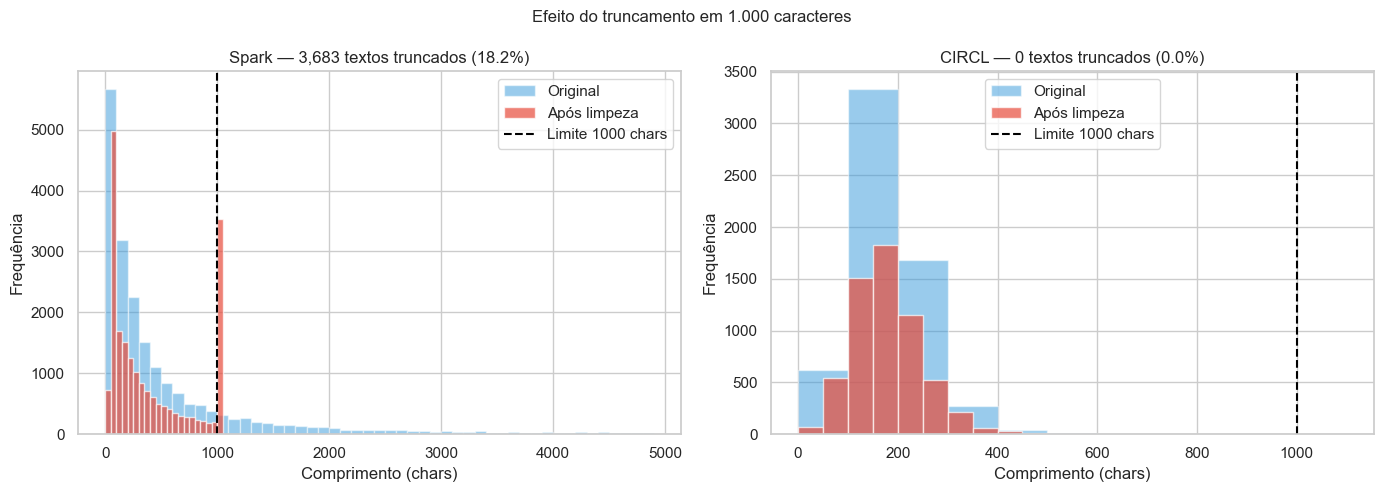


Porcentagem de textos truncados por classe:
  Spark:
    Alta  : 40.6% truncados
    Média : 18.0% truncados
    Baixa : 16.6% truncados
  CIRCL:
    Alta  : 0.0% truncados
    Média : 0.0% truncados
    Baixa : 0.0% truncados


In [4]:
# ── 3.1 Efeito do truncamento em 1000 caracteres ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Efeito do truncamento em 1.000 caracteres', fontsize=12)

for ax, (df, nome) in zip(axes, [(df_spark_full, 'Spark'), (df_circl_full, 'CIRCL')]):
    raw_len  = df['text_raw'].str.len()
    clean_len = df['text'].str.len()
    truncados = (raw_len > 1000).sum()
    pct_trunc = truncados / len(df) * 100

    bins = range(0, min(int(raw_len.max()) + 200, 5000), 100)
    ax.hist(raw_len.clip(upper=5000), bins=bins, alpha=0.5, label='Original', color='#3498db')
    ax.hist(clean_len, bins=range(0, 1100, 50), alpha=0.7, label='Após limpeza', color='#e74c3c')
    ax.axvline(1000, color='black', linestyle='--', linewidth=1.5, label='Limite 1000 chars')
    ax.set_title(f'{nome} — {truncados:,} textos truncados ({pct_trunc:.1f}%)')
    ax.set_xlabel('Comprimento (chars)'); ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'preproc_truncamento.png', dpi=150, bbox_inches='tight')
plt.show()

# Detalhamento por classe
print('\nPorcentagem de textos truncados por classe:')
for df, nome in [(df_spark_full, 'Spark'), (df_circl_full, 'CIRCL')]:
    print(f'  {nome}:')
    for cls in CLASSES:
        sub = df[df['label'] == cls]
        pct = (sub['text_raw'].str.len() > 1000).mean() * 100
        print(f'    {cls:6s}: {pct:.1f}% truncados')

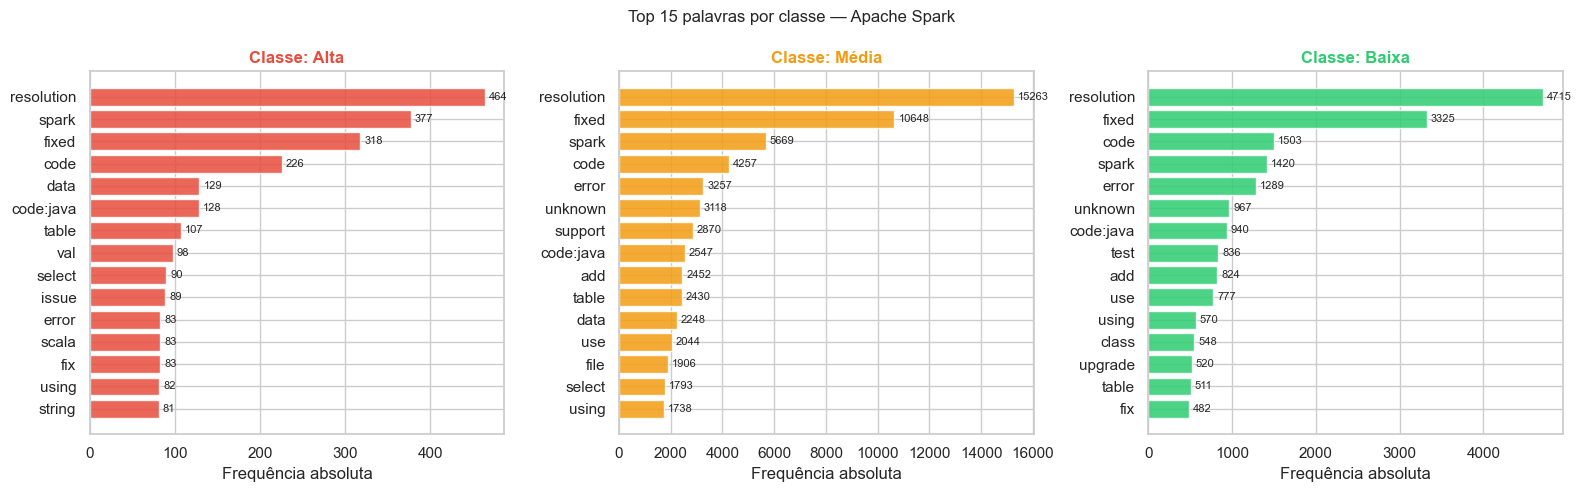

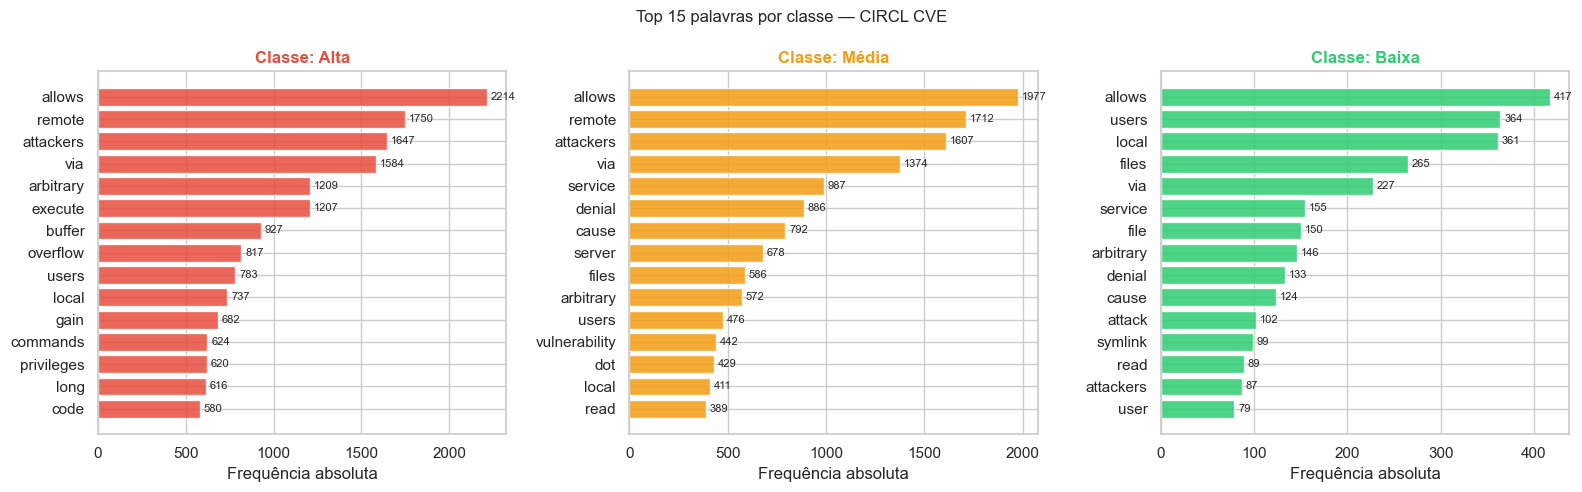

In [5]:
# ── 3.2 Termos mais frequentes por classe ─────────────────────────────────────

def top_tokens(df, classe, n=20, stopwords=STOPWORDS):
    """Retorna os n tokens mais frequentes em textos de uma classe (sem stopwords)."""
    textos = df[df['label'] == classe]['text']
    words  = []
    for t in textos:
        # Tokenização simples: split por espaço + remove pontuação
        for w in t.split():
            w = w.strip(string.punctuation)
            if len(w) > 2 and w not in stopwords:
                words.append(w)
    return Counter(words).most_common(n)


def plot_top_tokens(df, dataset_name, n=15):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Top {n} palavras por classe — {dataset_name}', fontsize=12)

    for ax, cls in zip(axes, CLASSES):
        tokens = top_tokens(df, cls, n=n)
        words, counts = zip(*tokens) if tokens else ([], [])
        bars = ax.barh(list(reversed(words)), list(reversed(counts)),
                       color=CORES[cls], edgecolor='white', alpha=0.85)
        ax.set_title(f'Classe: {cls}', color=CORES[cls], fontweight='bold')
        ax.set_xlabel('Frequência absoluta')
        for bar, val in zip(bars, reversed(counts)):
            ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                    str(val), va='center', fontsize=8)

    plt.tight_layout()
    fname = f'preproc_tokens_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


plot_top_tokens(df_spark_full, 'Apache Spark')
plot_top_tokens(df_circl_full, 'CIRCL CVE')

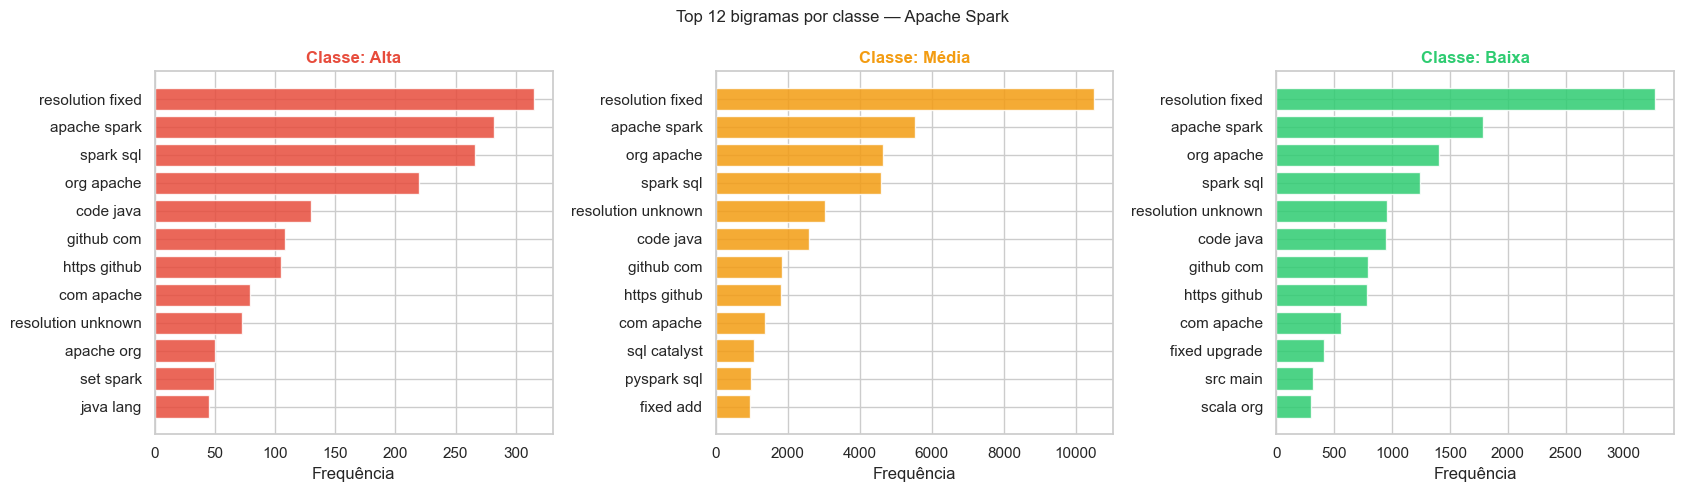

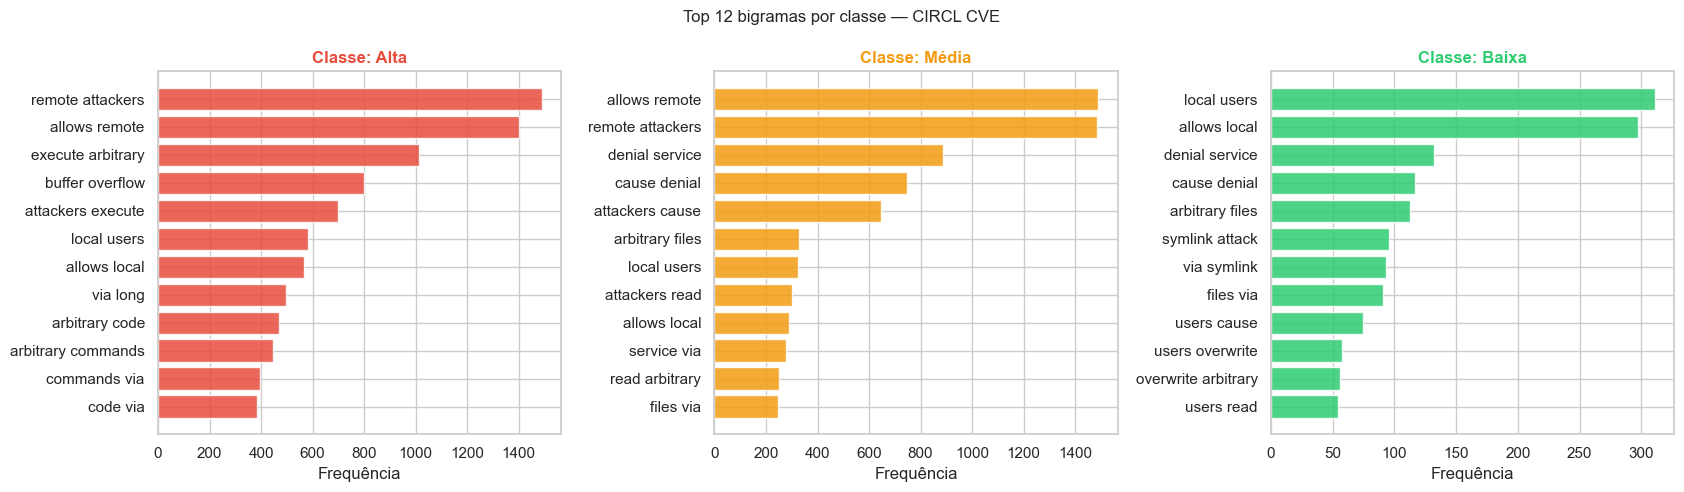

In [6]:
# ── 3.3 Bigramas mais frequentes por classe ───────────────────────────────────

def top_ngrams(df, classe, n=15, ngram_range=(2, 2)):
    """Extrai os n n-gramas mais frequentes para uma classe usando CountVectorizer."""
    textos = df[df['label'] == classe]['text'].tolist()
    vec = CountVectorizer(
        ngram_range=ngram_range,
        stop_words=list(STOPWORDS),
        max_features=500,
        min_df=2,
    )
    try:
        X = vec.fit_transform(textos)
    except ValueError:
        return []
    freqs = np.asarray(X.sum(axis=0)).flatten()
    vocab = {v: k for k, v in vec.vocabulary_.items()}
    top   = sorted(zip(freqs, [vocab[i] for i in range(len(freqs))]), reverse=True)[:n]
    return [(gram, freq) for freq, gram in top]


def plot_ngrams(df, dataset_name, n=12):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f'Top {n} bigramas por classe — {dataset_name}', fontsize=12)

    for ax, cls in zip(axes, CLASSES):
        grams = top_ngrams(df, cls, n=n)
        if not grams:
            ax.set_title(f'{cls} — sem bigramas'); continue
        words, counts = zip(*grams)
        ax.barh(list(reversed(words)), list(reversed(counts)),
                color=CORES[cls], edgecolor='white', alpha=0.85)
        ax.set_title(f'Classe: {cls}', color=CORES[cls], fontweight='bold')
        ax.set_xlabel('Frequência')

    plt.tight_layout()
    fname = f'preproc_bigrams_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


plot_ngrams(df_spark_full, 'Apache Spark')
plot_ngrams(df_circl_full, 'CIRCL CVE')

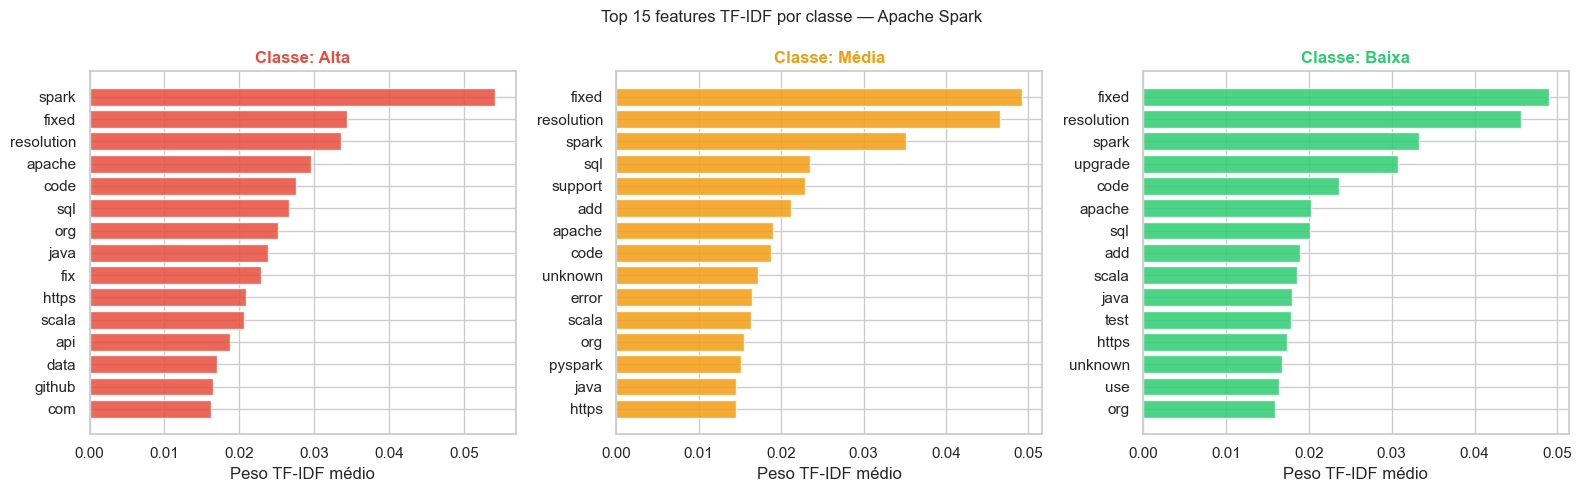

Salvo: resultados/preproc_tfidf_apache_spark.png


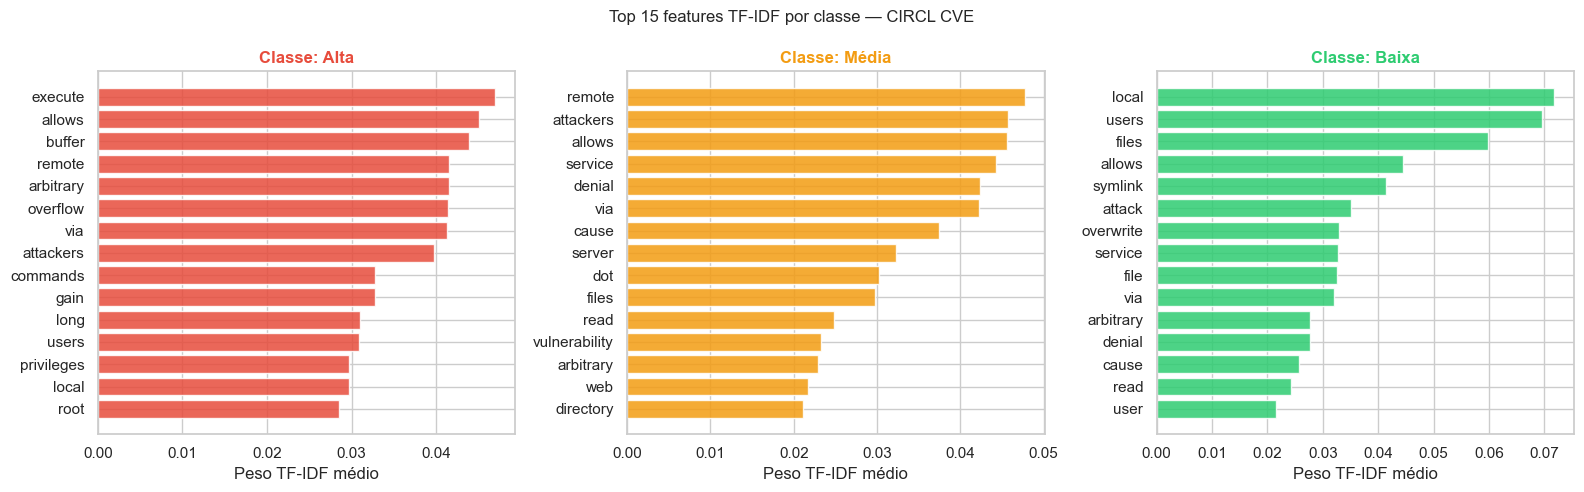

Salvo: resultados/preproc_tfidf_circl_cve.png


In [7]:
# ── 3.4 Top features TF-IDF por classe (média dos pesos) ─────────────────────
#
# Treinamos um TF-IDF em todo o dataset e calculamos o peso médio de cada
# token para cada classe. Isso revela o que o TF-IDF "enxerga" como
# discriminativo por classe — independentemente do classificador.

def plot_tfidf_top_features(df, dataset_name, n=15):
    tfidf = TfidfVectorizer(max_features=10_000, sublinear_tf=True,
                            stop_words=list(STOPWORDS))
    X = tfidf.fit_transform(df['text'])
    vocab = np.array(tfidf.get_feature_names_out())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Top {n} features TF-IDF por classe — {dataset_name}', fontsize=12)

    for ax, cls in zip(axes, CLASSES):
        mask       = df['label'].values == cls
        mean_tfidf = np.asarray(X[mask].mean(axis=0)).flatten()
        top_idx    = mean_tfidf.argsort()[::-1][:n]
        top_words  = vocab[top_idx]
        top_vals   = mean_tfidf[top_idx]

        ax.barh(list(reversed(top_words)), list(reversed(top_vals)),
                color=CORES[cls], edgecolor='white', alpha=0.85)
        ax.set_title(f'Classe: {cls}', color=CORES[cls], fontweight='bold')
        ax.set_xlabel('Peso TF-IDF médio')

    plt.tight_layout()
    fname = f'preproc_tfidf_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Salvo: resultados/{fname}')


plot_tfidf_top_features(df_spark_full, 'Apache Spark')
plot_tfidf_top_features(df_circl_full, 'CIRCL CVE')

In [8]:
# ── 3.5 Exemplos reais de textos por classe ───────────────────────────────────
#
# Verificação qualitativa: os rótulos fazem sentido? O texto é informativo?

print('=== Exemplos de texto por classe — Apache Spark ===\n')
for cls in CLASSES:
    amostras = df_spark_full[df_spark_full['label'] == cls]['text'].sample(2, random_state=SEED)
    print(f'--- {cls} ---')
    for i, txt in enumerate(amostras, 1):
        print(f'  [{i}] {txt[:300]}...')
    print()

print('=== Exemplos de texto por classe — CIRCL CVE ===\n')
for cls in CLASSES:
    amostras = df_circl_full[df_circl_full['label'] == cls]['text'].sample(2, random_state=SEED)
    print(f'--- {cls} ---')
    for i, txt in enumerate(amostras, 1):
        print(f'  [{i}] {txt[:300]}...')
    print()

=== Exemplos de texto por classe — Apache Spark ===

--- Alta ---
  [1] resolution: fixed | star expansion after outer join asymmetrically includes joining key when star expansion is used on left side of a join, the result will include joining key, while on the right side of join it doesn't. i would expect the behaviour to be symmetric (either include on both sides or o...
  [2] resolution: fixed | array_insert should fail with 0 index...

--- Média ---
  [1] resolution: unknown | support drop multi-level partition v2 table with partial partition spec...
  [2] resolution: fixed | correct csv schema inference and data parsing behavior on columns with mixed dates and timestamps in this ticket https://issues.apache.org/jira/browse/spark-39469, we introduced the support of date type in csv schema inference. the schema inference behavior on date time columns n...

--- Baixa ---
  [1] resolution: fixed | images used in pyspark documentation still use koalas images in [transform and apply a f

---
## Seção 4 — Balanceamento de Classes

### Estratégia: Real-First + SMOTE dentro do fold

**Etapa 1 — Undersampling real-first** (`make_balanced_sample`):
- Classes com **mais** de `N_PER_CLASS` amostras → subamostradas para `N_PER_CLASS`
- Classes com **menos** de `N_PER_CLASS` amostras → mantidas inteiras

**Etapa 2 — SMOTE dentro do fold** (via `ImbPipeline`):
- Em cada fold, SMOTE gera amostras sintéticas **só no treino**
- O fold de **teste** nunca vê amostras sintéticas → sem data leakage

> **SMOTE:** Para dois vizinhos $x_i$ e $x_{nn}$, gera $x_{new} = x_i + \lambda(x_{nn} - x_i)$, $\lambda \sim U(0,1)$

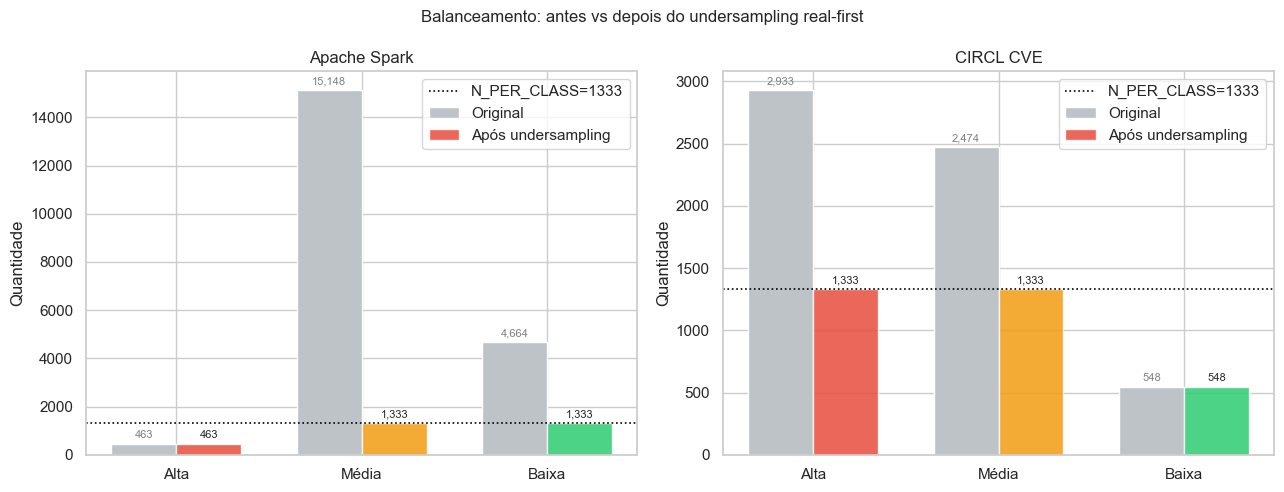

Após undersampling:
  Spark: 3129 amostras total
    Alta  : 463 (14.8%)
    Média : 1,333 (42.6%)
    Baixa : 1,333 (42.6%)
  CIRCL: 3214 amostras total
    Alta  : 1,333 (41.5%)
    Média : 1,333 (41.5%)
    Baixa : 548 (17.1%)


In [9]:
def make_balanced_sample(df, n_per_class=N_PER_CLASS, label_col='label', random_state=SEED):
    """Undersampling das classes maioritárias para n_per_class; minoritárias ficam intactas."""
    groups = []
    for label, group in df.groupby(label_col):
        n = min(len(group), n_per_class)
        groups.append(resample(group, replace=False, n_samples=n, random_state=random_state))
    return pd.concat(groups).sample(frac=1, random_state=random_state).reset_index(drop=True)


df_spark = make_balanced_sample(df_spark_full)
df_circl = make_balanced_sample(df_circl_full)

# ── Visualização: antes vs depois do undersampling ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Balanceamento: antes vs depois do undersampling real-first', fontsize=12)

for ax, (df_orig, df_bal, nome) in zip(axes, [
    (df_spark_full, df_spark, 'Apache Spark'),
    (df_circl_full, df_circl, 'CIRCL CVE'),
]):
    x = np.arange(len(CLASSES))
    w = 0.35
    antes  = [df_orig['label'].value_counts().reindex(CLASSES)[c] for c in CLASSES]
    depois = [df_bal['label'].value_counts().reindex(CLASSES)[c]  for c in CLASSES]

    b1 = ax.bar(x - w/2, antes,  w, label='Original', color='#bdc3c7', edgecolor='white')
    b2 = ax.bar(x + w/2, depois, w, label='Após undersampling', color=[CORES[c] for c in CLASSES],
                edgecolor='white', alpha=0.85)

    for bar, val in zip(b1, antes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(antes)*0.01,
                f'{val:,}', ha='center', va='bottom', fontsize=8, color='gray')
    for bar, val in zip(b2, depois):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(antes)*0.01,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(CLASSES)
    ax.set_title(nome); ax.set_ylabel('Quantidade')
    ax.legend()

    # Linha de N_PER_CLASS
    ax.axhline(N_PER_CLASS, color='black', linestyle=':', linewidth=1.2,
               label=f'N_PER_CLASS={N_PER_CLASS}')
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'balanceamento_antes_depois.png', dpi=150, bbox_inches='tight')
plt.show()

print('Após undersampling:')
for df, nome in [(df_spark, 'Spark'), (df_circl, 'CIRCL')]:
    print(f'  {nome}: {len(df)} amostras total')
    for cls in CLASSES:
        n = (df['label'] == cls).sum()
        print(f'    {cls:6s}: {n:,} ({n/len(df)*100:.1f}%)')

---
## Seção 5 — Representação Textual: Embeddings Qwen3

O **Qwen3-Embedding-0.6B** transforma cada texto em um vetor denso de 1024 dimensões.
Textos semanticamente similares ficam próximos no espaço vetorial.

Os embeddings são **pré-calculados** (modelo congelado) e armazenados em cache `.npy`.

> **Primeira execução:** download ~600 MB + inferência ~17 min em CPU.  
> **Execuções seguintes:** carrega do cache em segundos.

In [10]:
def embed_texts(texts, cache_name, model_name=EMBED_MODEL, batch_size=64,
                ollama_url='http://localhost:11434'):
    """Gera embeddings via Ollama API com cache em disco."""
    import requests
    model_tag  = model_name.replace(':', '_').replace('/', '_')
    cache_path = DATA_DIR / f'emb_{cache_name}_{model_tag}.npy'
    if cache_path.exists():
        emb = np.load(str(cache_path))
        print(f'Cache: {cache_path} → shape {emb.shape}')
        return emb
    print(f'Gerando embeddings com {model_name} via Ollama ({len(texts)} textos)...')
    all_emb = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Batches'):
        batch = texts[i:i + batch_size]
        r = requests.post(
            f'{ollama_url}/api/embed',
            json={'model': model_name, 'input': batch},
            timeout=120,
        )
        r.raise_for_status()
        all_emb.extend(r.json()['embeddings'])
    emb = np.array(all_emb, dtype=np.float32)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    emb = emb / np.maximum(norms, 1e-12)
    np.save(str(cache_path), emb)
    print(f'Salvo: {cache_path} | shape {emb.shape}')
    return emb


print('Gerando embeddings para Spark...')
emb_spark = embed_texts(df_spark['text'].tolist(), cache_name='spark_balanced')

print('\nGerando embeddings para CIRCL...')
emb_circl = embed_texts(df_circl['text'].tolist(), cache_name='circl_balanced')

print(f'\nSpark: {emb_spark.shape} | CIRCL: {emb_circl.shape}')

Gerando embeddings para Spark...
Gerando embeddings com qwen3-embedding:0.6b via Ollama (3129 textos)...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

Salvo: ..\data\emb_spark_balanced_qwen3-embedding_0.6b.npy | shape (3129, 1024)

Gerando embeddings para CIRCL...
Gerando embeddings com qwen3-embedding:0.6b via Ollama (3214 textos)...


Batches:   0%|          | 0/51 [00:00<?, ?it/s]

Salvo: ..\data\emb_circl_balanced_qwen3-embedding_0.6b.npy | shape (3214, 1024)

Spark: (3129, 1024) | CIRCL: (3214, 1024)


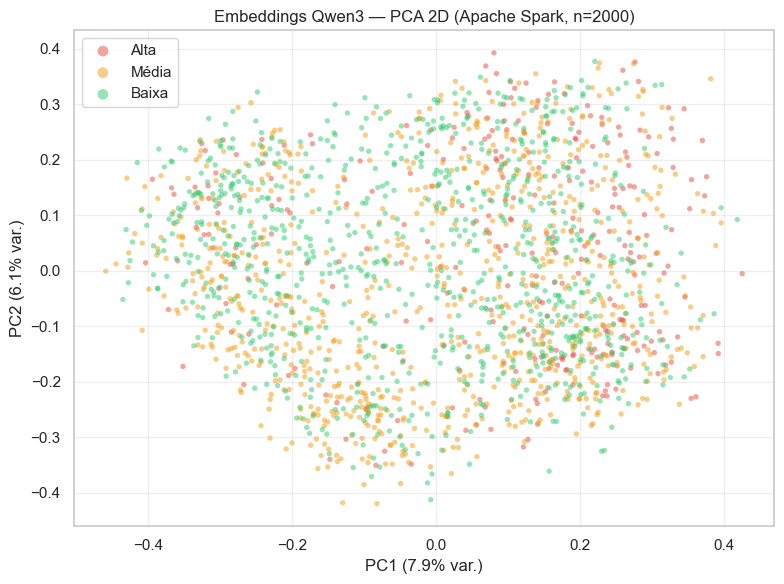

Variância explicada pelos 2 PCs: 14.0%


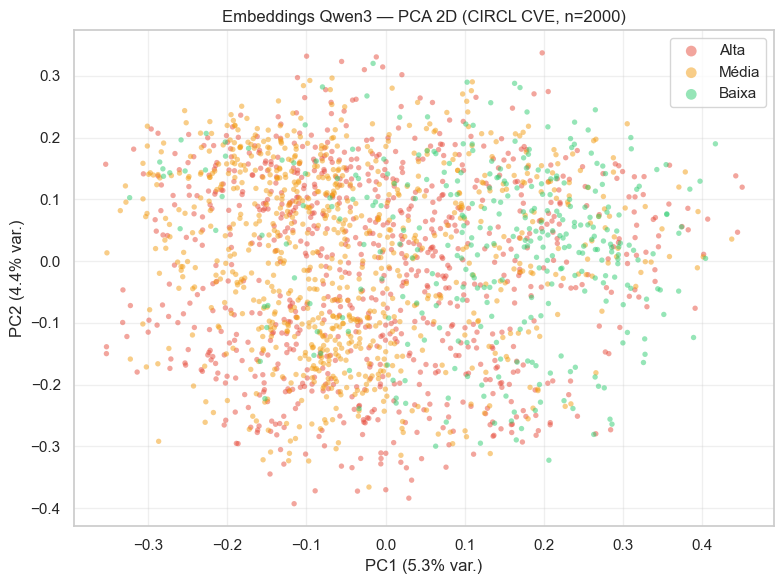

Variância explicada pelos 2 PCs: 9.7%


In [11]:
# ── Visualização dos embeddings com PCA (projeção 2D) ─────────────────────────
#
# PCA reduz 1024 → 2 dimensões para inspecionar visualmente a separabilidade
# das classes no espaço de embeddings. Clusters bem separados sugerem que
# os embeddings capturam informação discriminativa.

from sklearn.decomposition import PCA

def plot_embeddings_pca(emb, y, dataset_name):
    pca = PCA(n_components=2, random_state=SEED)
    # Subsample para agilidade (máx 2000 pontos)
    n = min(len(emb), 2000)
    idx = np.random.choice(len(emb), n, replace=False)
    emb_2d = pca.fit_transform(emb[idx])
    y_sub  = np.array(y)[idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    for cls in CLASSES:
        mask = y_sub == cls
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=CORES[cls], label=cls, alpha=0.5, s=15, edgecolors='none')
    var = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var.)')
    ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var.)')
    ax.set_title(f'Embeddings Qwen3 — PCA 2D ({dataset_name}, n={n})')
    ax.legend(markerscale=2); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f'embeddings_pca_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Variância explicada pelos 2 PCs: {(var.sum()*100):.1f}%')


plot_embeddings_pca(emb_spark, df_spark['label'].values, 'Apache Spark')
plot_embeddings_pca(emb_circl, df_circl['label'].values, 'CIRCL CVE')

---
## Seção 6 — Framework de Avaliação

### Métricas utilizadas

| Métrica | Fórmula | Por que usar |
|---|---|---|
| **F1-macro** | Média do F1 por classe | Métrica principal; peso igual entre classes |
| **Acurácia** | Acertos / Total | Intuicível, mas enganosa com desbalanceamento |
| **Precisão-macro** | Média da precisão por classe | Custo de falsos positivos |
| **Recall-macro** | Média do recall por classe | Custo de falsos negativos (crítico para Alta) |
| **MCC** | Correlação Matthews | Robusto ao desbalanceamento; [-1, 1] |
| **Kappa** | Acordo além do acaso | 0=aleatório, 1=perfeito |
| **F1 por classe** | F1 de Alta, Média, Baixa | O modelo aprende a classe rara? |

In [12]:
def compute_metrics(y_true, y_pred, classes=CLASSES):
    """Calcula F1-macro, Acurácia, Precisão, Recall, MCC, Kappa e F1 por classe."""
    f1_per = f1_score(y_true, y_pred, labels=classes, average=None, zero_division=0)
    m = {
        'F1-macro':  f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Acurácia':  accuracy_score(y_true, y_pred),
        'Precisão':  precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'MCC':       matthews_corrcoef(y_true, y_pred),
        'Kappa':     cohen_kappa_score(y_true, y_pred),
    }
    for cls, f1 in zip(classes, f1_per):
        m[f'F1-{cls}'] = f1
    return m


def safe_k(y, default=3):
    min_count = pd.Series(y).value_counts().min()
    return max(1, min(default, min_count - 1))


def index_X(X, idx):
    if isinstance(X, np.ndarray) or hasattr(X, 'tocsr'):
        return X[idx]
    return [X[i] for i in idx]


def evaluate_pipeline(pipeline, X, y, n_splits=N_OUTER, seed=SEED):
    """Validação cruzada estratificada com SMOTE apenas no fold de treino."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y  = np.array(y)
    records, y_true_all, y_pred_all = [], [], []

    for tr_idx, te_idx in cv.split(X, y):
        X_tr, X_te = index_X(X, tr_idx), index_X(X, te_idx)
        y_tr, y_te = y[tr_idx], y[te_idx]
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_te)
        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)
        records.append(compute_metrics(y_te, y_pred))

    folds_df = pd.DataFrame(records)
    return {
        'folds':   folds_df,
        'summary': folds_df.agg(['mean', 'std']),
        'y_true':  np.array(y_true_all),
        'y_pred':  np.array(y_pred_all),
    }


def print_summary(result, nome):
    m = result['summary']
    print(f'\n── {nome} ──')
    for col in ['F1-macro','Acurácia','Precisão','Recall','MCC','Kappa'] + [f'F1-{c}' for c in CLASSES]:
        print(f'  {col:12s}: {m.loc["mean",col]:.4f} ± {m.loc["std",col]:.4f}')

print('Framework definido.')

Framework definido.


---
## Seção 6.5 — Ajuste de Hiperparâmetros (RandomizedSearchCV)

Antes de avaliar os baselines com validação cruzada completa, buscamos os melhores
hiperparâmetros via **RandomizedSearchCV** (20 iterações × 5 folds internos).

### Por que fazer isso antes dos baselines?

- Treinar baselines com hiperparâmetros padrão (default) é um **piso**, não um teto
- Hiperparâmetros otimizados garantem que a comparação entre modelos e o stacking
  seja justa — estamos comparando cada modelo no seu melhor, não com configs arbitrárias
- O SMOTE é aplicado **dentro de cada fold** do search → sem data leakage

### O que está sendo buscado?

| Modelo | Hiperparâmetro | Faixa |
|---|---|---|
| LogReg | C (regularização) | [0.01, 100] em escala log |
| XGBoost | n_estimators, max_depth, learning_rate | [100–400], [3–8], [0.01–0.32] |
| LightGBM | n_estimators, num_leaves, learning_rate | [100–400], [20–60], [0.01–0.32] |

> NB, SVM e RF ficam com defaults pois já são robustos em suas configurações padrão.

In [14]:
class XGBStringWrapper(BaseEstimator, ClassifierMixin):
    """XGBoost com LabelEncoder interno para aceitar rótulos em string."""
    def __init__(self, n_estimators=200, learning_rate=0.1, max_depth=6,
                 subsample=0.8, colsample_bytree=0.8, random_state=SEED):
        self.n_estimators = n_estimators; self.learning_rate = learning_rate
        self.max_depth = max_depth; self.subsample = subsample
        self.colsample_bytree = colsample_bytree; self.random_state = random_state

    def fit(self, X, y):
        self._le = LabelEncoder()
        y_enc = self._le.fit_transform(y)
        self._clf = XGBClassifier(
            n_estimators=self.n_estimators, learning_rate=self.learning_rate,
            max_depth=self.max_depth, subsample=self.subsample,
            colsample_bytree=self.colsample_bytree, eval_metric='mlogloss',
            random_state=self.random_state, verbosity=0,
            **XGB_GPU,
        )
        self._clf.fit(X, y_enc)
        self.classes_ = self._le.classes_
        return self

    def predict(self, X):
        return self._le.inverse_transform(self._clf.predict(X))

    def predict_proba(self, X):
        return self._clf.predict_proba(X)



from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint

SEARCH_FOLDS  = 5
N_ITER_SEARCH = 20

_search_cv = StratifiedKFold(n_splits=SEARCH_FOLDS, shuffle=True, random_state=SEED)


def busca_hiperparametros(df, emb, dataset_name):
    """RandomizedSearchCV (20 iterações × 5 folds) para LogReg, XGBoost e LightGBM.

    SMOTE é aplicado dentro de cada fold do search para evitar data leakage.
    Retorna dict com os melhores hiperparâmetros — usado por build_baselines() e
    evaluate_stacking() para substituir os defaults.
    """
    texts = df['text'].tolist()
    y     = df['label'].values
    bp    = {}

    print(f'\n=== Busca de Hiperparâmetros — {dataset_name}'
          f' ({N_ITER_SEARCH} iter × {SEARCH_FOLDS} folds) ===')

    # ── LogReg + TF-IDF ───────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True)),
        ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',   LogisticRegression(max_iter=1000, random_state=SEED)),
    ])
    rs = RandomizedSearchCV(
        pipe, {'clf__C': np.logspace(-2, 2, 200)},
        n_iter=N_ITER_SEARCH, scoring='f1_macro', cv=_search_cv,
        random_state=SEED, n_jobs=-1, verbose=0,
    )
    rs.fit(texts, y)
    bp['logreg_C'] = float(rs.best_params_['clf__C'])
    print(f'  LogReg    C={bp["logreg_C"]:.5f}          → F1-macro={rs.best_score_:.4f}')

    # ── XGBoost + Emb ─────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',    XGBStringWrapper()),
    ])
    rs = RandomizedSearchCV(
        pipe,
        {
            'clf__n_estimators':  sp_randint(100, 400),
            'clf__max_depth':     sp_randint(3, 8),
            'clf__learning_rate': np.logspace(-2, -0.5, 100),
        },
        n_iter=N_ITER_SEARCH, scoring='f1_macro', cv=_search_cv,
        random_state=SEED, n_jobs=1, verbose=0,
    )
    rs.fit(emb, y)
    bp['xgb_n']  = int(rs.best_params_['clf__n_estimators'])
    bp['xgb_d']  = int(rs.best_params_['clf__max_depth'])
    bp['xgb_lr'] = float(rs.best_params_['clf__learning_rate'])
    print(f'  XGBoost   n={bp["xgb_n"]:3d} d={bp["xgb_d"]} lr={bp["xgb_lr"]:.5f}  → F1-macro={rs.best_score_:.4f}')

    # ── LightGBM + Emb ────────────────────────────────────────────────────────
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
        ('clf',    LGBMClassifier(random_state=SEED, verbose=-1, **LGBM_GPU)),
    ])
    rs = RandomizedSearchCV(
        pipe,
        {
            'clf__n_estimators':  sp_randint(100, 400),
            'clf__num_leaves':    sp_randint(20, 60),
            'clf__learning_rate': np.logspace(-2, -0.5, 100),
        },
        n_iter=N_ITER_SEARCH, scoring='f1_macro', cv=_search_cv,
        random_state=SEED, n_jobs=1, verbose=0,
    )
    rs.fit(emb, y)
    bp['lgbm_n']      = int(rs.best_params_['clf__n_estimators'])
    bp['lgbm_leaves'] = int(rs.best_params_['clf__num_leaves'])
    bp['lgbm_lr']     = float(rs.best_params_['clf__learning_rate'])
    print(f'  LightGBM  n={bp["lgbm_n"]:3d} leaves={bp["lgbm_leaves"]:2d} lr={bp["lgbm_lr"]:.5f}  → F1-macro={rs.best_score_:.4f}')

    return bp


bp_spark = busca_hiperparametros(df_spark, emb_spark, 'Apache Spark')
bp_circl = busca_hiperparametros(df_circl, emb_circl, 'CIRCL CVE')


=== Busca de Hiperparâmetros — Apache Spark (20 iter × 5 folds) ===
  LogReg    C=0.81198          → F1-macro=0.5342
  XGBoost   n=188 d=6 lr=0.01810  → F1-macro=0.5082
  LightGBM  n=314 leaves=30 lr=0.17475  → F1-macro=0.5012

=== Busca de Hiperparâmetros — CIRCL CVE (20 iter × 5 folds) ===
  LogReg    C=0.81198          → F1-macro=0.7119
  XGBoost   n=363 d=6 lr=0.07833  → F1-macro=0.6621
  LightGBM  n=370 leaves=22 lr=0.07833  → F1-macro=0.6582


---
## Seção 7 — Classificadores Base (Baselines)

| # | Modelo | Representação | Biblioteca | Justificativa |
|---|---|---|---|---|
| 1 | Complement Naive Bayes | TF-IDF | sklearn | Baseline Lamkanfi; robusto ao desbalanceamento |
| 2 | Regressão Logística | TF-IDF | sklearn | Linear, interpretável |
| 3 | SVM Linear (calibrado) | TF-IDF | sklearn | Margem máxima em alta dimensão |
| 4 | Random Forest | Embeddings | sklearn | Ensemble de árvores, não-linear |
| 5 | **XGBoost** | Embeddings | **xgboost** | Gradient boosting (não-sklearn) |
| 6 | **LightGBM** | Embeddings | **lightgbm** | Boosting leaf-wise (não-sklearn) |

Todos usam `ImbPipeline`: SMOTE aplicado **dentro de cada fold de treino**.

In [15]:
def build_baselines(params=None):
    """Constrói os classificadores base.

    params: dict retornado por busca_hiperparametros(); se None usa defaults.
    """
    p           = params or {}
    logreg_C    = p.get('logreg_C',    1.0)
    xgb_n       = p.get('xgb_n',       200)
    xgb_d       = p.get('xgb_d',       6)
    xgb_lr      = p.get('xgb_lr',      0.1)
    lgbm_n      = p.get('lgbm_n',      300)
    lgbm_leaves = p.get('lgbm_leaves',  31)
    lgbm_lr     = p.get('lgbm_lr',     0.1)

    return {
        'NB (TF-IDF)': (ImbPipeline([
            ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True)),
            ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',   ComplementNB()),
        ]), 'text'),
        'LogReg (TF-IDF)': (ImbPipeline([
            ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True)),
            ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',   LogisticRegression(max_iter=1000, C=logreg_C, random_state=SEED)),
        ]), 'text'),
        'SVM (TF-IDF)': (ImbPipeline([
            ('tfidf', TfidfVectorizer(max_features=20_000, sublinear_tf=True)),
            ('smote', SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',   CalibratedClassifierCV(LinearSVC(max_iter=3000, random_state=SEED), cv=3)),
        ]), 'text'),
        'RF (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
        ]), 'emb'),
        'XGBoost (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    XGBStringWrapper(n_estimators=xgb_n, max_depth=xgb_d, learning_rate=xgb_lr)),
        ]), 'emb'),
        'LightGBM (Emb)': (ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=SEED, k_neighbors=3)),
            ('clf',    LGBMClassifier(n_estimators=lgbm_n, learning_rate=lgbm_lr,
                                      num_leaves=lgbm_leaves, random_state=SEED, verbose=-1,
                                      **LGBM_GPU)),
        ]), 'emb'),
    }


def run_baselines(df, emb, dataset_name, params=None):
    texts = df['text'].tolist()
    y     = df['label'].values
    results = {}
    print(f'\n=== Baselines — {dataset_name} ===')
    for nome, (pipeline, xtype) in build_baselines(params).items():
        X = texts if xtype == 'text' else emb
        print(f'  {nome}...', end=' ', flush=True)
        res = evaluate_pipeline(pipeline, X, y)
        results[nome] = res
        f1m = res['summary'].loc['mean', 'F1-macro']
        acc = res['summary'].loc['mean', 'Acurácia']
        print(f'F1-macro={f1m:.4f} | Acurácia={acc:.4f}')
    return results

print('Baselines definidos.')

Baselines definidos.


In [16]:
results_spark = run_baselines(df_spark, emb_spark, 'Apache Spark', params=bp_spark)
for nome, res in results_spark.items():
    print_summary(res, nome)


=== Baselines — Apache Spark ===
  NB (TF-IDF)... F1-macro=0.4728 | Acurácia=0.4813
  LogReg (TF-IDF)... F1-macro=0.5381 | Acurácia=0.5650
  SVM (TF-IDF)... F1-macro=0.5100 | Acurácia=0.5634
  RF (Emb)... F1-macro=0.4999 | Acurácia=0.5436
  XGBoost (Emb)... F1-macro=0.5075 | Acurácia=0.5337
  LightGBM (Emb)... F1-macro=0.4963 | Acurácia=0.5449

── NB (TF-IDF) ──
  F1-macro    : 0.4728 ± 0.0299
  Acurácia    : 0.4813 ± 0.0307
  Precisão    : 0.5075 ± 0.0290
  Recall      : 0.5373 ± 0.0336
  MCC         : 0.2661 ± 0.0438
  Kappa       : 0.2457 ± 0.0411
  F1-Alta     : 0.3930 ± 0.0354
  F1-Média    : 0.4665 ± 0.0444
  F1-Baixa    : 0.5588 ± 0.0413

── LogReg (TF-IDF) ──
  F1-macro    : 0.5381 ± 0.0283
  Acurácia    : 0.5650 ± 0.0249
  Precisão    : 0.5327 ± 0.0268
  Recall      : 0.5526 ± 0.0331
  MCC         : 0.3104 ± 0.0413
  Kappa       : 0.3089 ± 0.0411
  F1-Alta     : 0.4299 ± 0.0550
  F1-Média    : 0.5651 ± 0.0308
  F1-Baixa    : 0.6192 ± 0.0341

── SVM (TF-IDF) ──
  F1-macro    :

In [17]:
results_circl = run_baselines(df_circl, emb_circl, 'CIRCL CVE', params=bp_circl)
for nome, res in results_circl.items():
    print_summary(res, nome)


=== Baselines — CIRCL CVE ===
  NB (TF-IDF)... F1-macro=0.6442 | Acurácia=0.6577
  LogReg (TF-IDF)... F1-macro=0.7119 | Acurácia=0.7256
  SVM (TF-IDF)... F1-macro=0.6887 | Acurácia=0.7091
  RF (Emb)... F1-macro=0.6444 | Acurácia=0.6652
  XGBoost (Emb)... F1-macro=0.6603 | Acurácia=0.6776
  LightGBM (Emb)... F1-macro=0.6495 | Acurácia=0.6711

── NB (TF-IDF) ──
  F1-macro    : 0.6442 ± 0.0223
  Acurácia    : 0.6577 ± 0.0263
  Precisão    : 0.6388 ± 0.0221
  Recall      : 0.6688 ± 0.0205
  MCC         : 0.4758 ± 0.0384
  Kappa       : 0.4713 ± 0.0389
  F1-Alta     : 0.7068 ± 0.0404
  F1-Média    : 0.6520 ± 0.0349
  F1-Baixa    : 0.5737 ± 0.0244

── LogReg (TF-IDF) ──
  F1-macro    : 0.7119 ± 0.0217
  Acurácia    : 0.7256 ± 0.0213
  Precisão    : 0.7066 ± 0.0204
  Recall      : 0.7219 ± 0.0257
  MCC         : 0.5679 ± 0.0345
  Kappa       : 0.5666 ± 0.0344
  F1-Alta     : 0.7683 ± 0.0355
  F1-Média    : 0.7121 ± 0.0244
  F1-Baixa    : 0.6553 ± 0.0422

── SVM (TF-IDF) ──
  F1-macro    : 0.

---
## Seção 8 — Seleção de Modelos: Friedman + Nemenyi

Com 6 modelos avaliados em 10 folds, aplicamos:

1. **Teste de Friedman** — H₀: todos os classificadores têm desempenho equivalente  
   Se p < 0.05: rejeita H₀ → há diferença entre pelo menos um par

2. **Nemenyi pós-hoc** — compara todos os pares; controla erro de Tipo I  
   Orienta a escolha dos membros do Stacking (preferimos modelos diversos)

> Usamos testes não-paramétricos porque com n=10 folds não é possível verificar
> normalidade dos resíduos com confiança (Demšar, 2006).


=== Seleção de Modelos — Apache Spark | métrica: F1-macro ===
         Modelo  Rank médio  F1-macro médio
LogReg (TF-IDF)         1.5          0.5381
   SVM (TF-IDF)         3.0          0.5100
  XGBoost (Emb)         3.3          0.5075
       RF (Emb)         4.1          0.4999
 LightGBM (Emb)         4.1          0.4963
    NB (TF-IDF)         5.0          0.4728

Friedman: χ²=20.7429, p=0.000906
  p < 0.05 → REJEITAMOS H₀ → aplicar Nemenyi pós-hoc

Matrix p-valores (Nemenyi):
                 NB (TF-IDF)  LogReg (TF-IDF)  SVM (TF-IDF)  RF (Emb)  XGBoost (Emb)  LightGBM (Emb)
NB (TF-IDF)           1.0000           0.0004        0.1594    0.8912         0.3241          0.8912
LogReg (TF-IDF)       0.0004           1.0000        0.4703    0.0232         0.2610          0.0232
SVM (TF-IDF)          0.1594           0.4703        1.0000    0.7770         0.9992          0.7770
RF (Emb)              0.8912           0.0232        0.7770    1.0000         0.9316          1.0000
XGBoost 

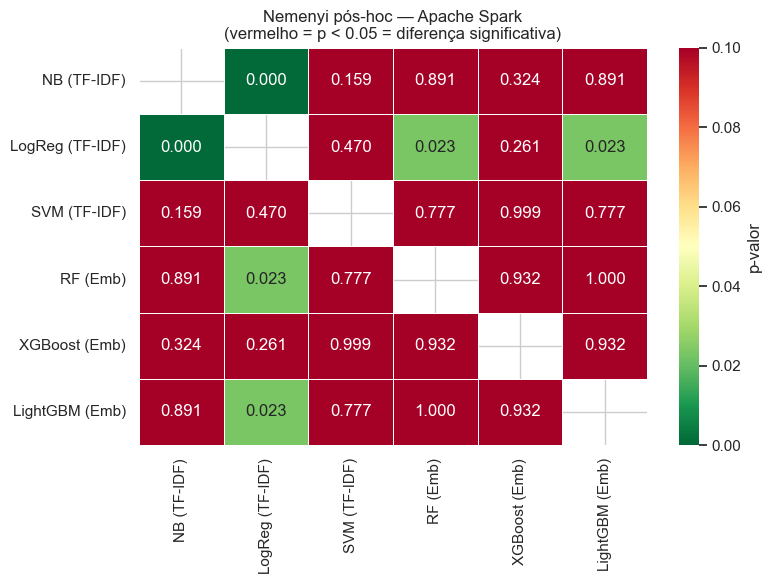


=== Seleção de Modelos — CIRCL CVE | métrica: F1-macro ===
         Modelo  Rank médio  F1-macro médio
LogReg (TF-IDF)         1.2          0.7119
   SVM (TF-IDF)         2.0          0.6887
  XGBoost (Emb)         3.5          0.6603
 LightGBM (Emb)         4.4          0.6495
    NB (TF-IDF)         4.8          0.6442
       RF (Emb)         5.1          0.6444

Friedman: χ²=36.0000, p=0.000001
  p < 0.05 → REJEITAMOS H₀ → aplicar Nemenyi pós-hoc

Matrix p-valores (Nemenyi):
                 NB (TF-IDF)  LogReg (TF-IDF)  SVM (TF-IDF)  RF (Emb)  XGBoost (Emb)  LightGBM (Emb)
NB (TF-IDF)           1.0000           0.0002        0.0106    0.9992         0.6292          0.9969
LogReg (TF-IDF)       0.0002           1.0000        0.9316    0.0000         0.0660          0.0018
SVM (TF-IDF)          0.0106           0.9316        1.0000    0.0029         0.4703          0.0474
RF (Emb)              0.9992           0.0000        0.0029    1.0000         0.3944          0.9607
XGBoost (Em

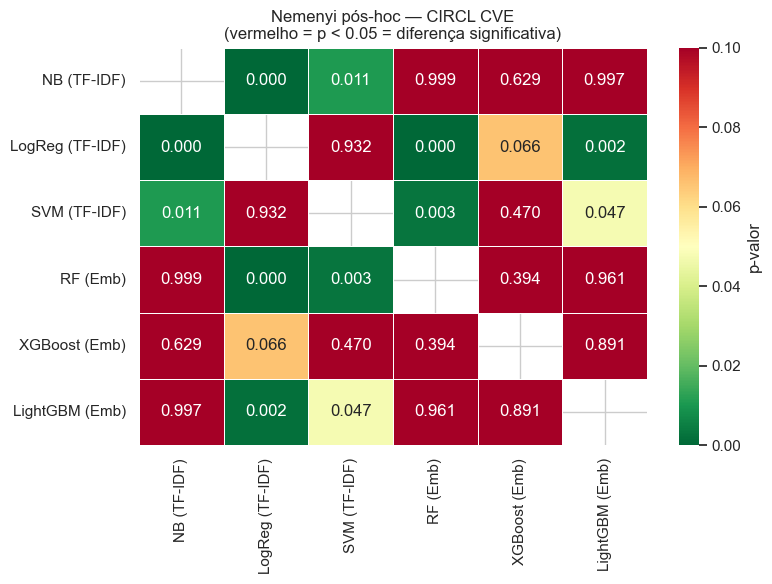

In [18]:
def selecao_modelos(results_dict, dataset_name, metrica='F1-macro'):
    nomes  = list(results_dict.keys())
    scores = np.array([results_dict[n]['folds'][metrica].values for n in nomes])

    print(f'\n=== Seleção de Modelos — {dataset_name} | métrica: {metrica} ===')

    # Ranking médio
    ranks = np.array([(-scores[:, f]).argsort().argsort() + 1
                      for f in range(scores.shape[1])]).T
    mean_ranks = ranks.mean(axis=1)
    rank_df = pd.DataFrame({
        'Modelo': nomes,
        'Rank médio': mean_ranks.round(2),
        f'{metrica} médio': scores.mean(axis=1).round(4),
    }).sort_values('Rank médio').reset_index(drop=True)
    print(rank_df.to_string(index=False))

    # Friedman
    stat, p = friedmanchisquare(*[scores[i] for i in range(len(nomes))])
    print(f'\nFriedman: χ²={stat:.4f}, p={p:.6f}')
    if p >= 0.05:
        print('  p ≥ 0.05 → sem diferença significativa entre os modelos.')
        return rank_df, None
    print('  p < 0.05 → REJEITAMOS H₀ → aplicar Nemenyi pós-hoc')

    # Nemenyi
    scores_df = pd.DataFrame(scores.T, columns=nomes)
    p_nem = sp.posthoc_nemenyi_friedman(scores_df)
    print('\nMatrix p-valores (Nemenyi):')
    print(p_nem.round(4).to_string())

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(p_nem, annot=True, fmt='.3f', cmap='RdYlGn_r',
                vmin=0, vmax=0.1, mask=np.eye(len(nomes), dtype=bool),
                ax=ax, linewidths=0.5, cbar_kws={'label': 'p-valor'})
    ax.set_title(f'Nemenyi pós-hoc — {dataset_name}\n(vermelho = p < 0.05 = diferença significativa)')
    plt.tight_layout()
    fname = f'nemenyi_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    return rank_df, p_nem


rank_spark, nem_spark = selecao_modelos(results_spark, 'Apache Spark')
rank_circl, nem_circl = selecao_modelos(results_circl, 'CIRCL CVE')

---
## Seção 9 — Sistema Híbrido: Stacking com OOF Aninhado

### Onde acontece a hibridização?

A hibridização ocorre **na montagem das meta-features** — as 12 colunas que o
meta-classificador recebe combinam saídas de **duas representações diferentes**:

```
Meta-features (12 colunas por amostra):
  cols 0–2  → P(Alta), P(Méd), P(Bx)  via  LogReg  + TF-IDF       ← frequência de termos
  cols 3–5  → P(Alta), P(Méd), P(Bx)  via  RF      + Embeddings    ┐
  cols 6–8  → P(Alta), P(Méd), P(Bx)  via  XGBoost + Embeddings    ├ semântica densa
  cols 9–11 → P(Alta), P(Méd), P(Bx)  via  LightGBM+ Embeddings    ┘
               └──── TF-IDF ────┘   └──────────── Embeddings ─────────────┘
                                               ▼
                              LogReg (meta) aprende o peso ideal de cada fonte
```

O meta-classificador não "vê" o texto diretamente — ele vê a **confiança de cada
modelo base** e aprende quando confiar mais no TF-IDF (para palavras-chave exatas)
e quando confiar mais nos embeddings (para semântica e paráfrases).

### Anti-leakage: predições Out-of-Fold (OOF)

As meta-features de treino são geradas com **inner CV** (5 folds):
cada amostra é predita por um modelo que **não a viu** no treino.

O SMOTE é aplicado:
- Dentro de cada **inner fold** para os modelos base
- Nos **meta-features OOF** para o meta-classificador
- Nunca nos dados de **teste**

Os hiperparâmetros dos modelos base vêm do `bp_spark` / `bp_circl` (Seção 6.5).

In [19]:
def reorder_proba(proba, clf_classes, target_classes):
    cls_list = list(clf_classes)
    idx = [cls_list.index(c) for c in target_classes if c in cls_list]
    return proba[:, idx]


def evaluate_stacking(df, emb, params=None, classes=CLASSES,
                      n_outer=N_OUTER, n_inner=N_INNER, seed=SEED):
    """Stacking com nested CV.

    Nível 0: LogReg+TF-IDF, RF+Emb, XGBoost+Emb, LightGBM+Emb
    Nível 1: LogReg treinado nas predições OOF (12 meta-features)

    A HIBRIDIZAÇÃO ocorre na montagem das meta-features:
      cols 0–2  = saída do LogReg+TF-IDF  (frequência de termos)
      cols 3–11 = saída dos modelos de Embeddings (semântica densa)
    O meta-LogReg aprende o peso ideal de cada fonte para cada classe.

    params: dict de busca_hiperparametros(); se None usa defaults.
    """
    p           = params or {}
    logreg_C    = p.get('logreg_C',    1.0)
    xgb_n       = p.get('xgb_n',       200)
    xgb_d       = p.get('xgb_d',       6)
    xgb_lr      = p.get('xgb_lr',      0.1)
    lgbm_n      = p.get('lgbm_n',      200)
    lgbm_leaves = p.get('lgbm_leaves',  31)
    lgbm_lr     = p.get('lgbm_lr',     0.1)

    texts    = df['text'].tolist()
    y        = df['label'].values
    le       = LabelEncoder().fit(classes)
    n_cls    = len(classes)
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=seed)
    inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=seed)
    records, y_true_all, y_pred_all = [], [], []

    for fold, (o_tr, o_te) in enumerate(outer_cv.split(emb, y), 1):
        print(f'  Fold {fold}/{n_outer}...', end=' ', flush=True)

        txt_tr = [texts[i] for i in o_tr];  txt_te = [texts[i] for i in o_te]
        emb_tr = emb[o_tr];                 emb_te = emb[o_te]
        y_tr   = y[o_tr];                   y_te   = y[o_te]

        tfidf  = TfidfVectorizer(max_features=20_000, sublinear_tf=True)
        scaler = StandardScaler()
        X_tfidf_tr = tfidf.fit_transform(txt_tr);  X_tfidf_te = tfidf.transform(txt_te)
        X_emb_tr   = scaler.fit_transform(emb_tr); X_emb_te   = scaler.transform(emb_te)

        # ── Inner CV: gerar OOF meta-features ────────────────────────────────
        oof = np.zeros((len(o_tr), 4 * n_cls))

        for i_tr, i_te in inner_cv.split(X_emb_tr, y_tr):
            k = safe_k(y_tr[i_tr])
            sm = SMOTE(random_state=seed, k_neighbors=k)

            # Clf 0: LogReg + TF-IDF → meta-features cols 0–2  [HIBRIDIZAÇÃO: fonte TF-IDF]
            Xs, ys = sm.fit_resample(X_tfidf_tr[i_tr], y_tr[i_tr])
            c0 = LogisticRegression(max_iter=1000, C=logreg_C, random_state=seed).fit(Xs, ys)
            oof[i_te, 0*n_cls:1*n_cls] = reorder_proba(c0.predict_proba(X_tfidf_tr[i_te]), c0.classes_, classes)

            # Clf 1: RF + Emb → meta-features cols 3–5  [HIBRIDIZAÇÃO: fonte Embeddings]
            Xs, ys = sm.fit_resample(X_emb_tr[i_tr], y_tr[i_tr])
            c1 = RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1).fit(Xs, ys)
            oof[i_te, 1*n_cls:2*n_cls] = reorder_proba(c1.predict_proba(X_emb_tr[i_te]), c1.classes_, classes)

            # Clf 2: XGBoost + Emb → meta-features cols 6–8  [HIBRIDIZAÇÃO: fonte Embeddings]
            y_tr_enc = le.transform(y_tr[i_tr])
            Xs_enc, ys_enc = sm.fit_resample(X_emb_tr[i_tr], y_tr_enc)
            c2 = XGBClassifier(
                n_estimators=xgb_n, learning_rate=xgb_lr, max_depth=xgb_d,
                eval_metric='mlogloss', random_state=seed, verbosity=0,
                **XGB_GPU,
            ).fit(Xs_enc, ys_enc)
            oof[i_te, 2*n_cls:3*n_cls] = c2.predict_proba(X_emb_tr[i_te])

            # Clf 3: LightGBM + Emb → meta-features cols 9–11  [HIBRIDIZAÇÃO: fonte Embeddings]
            Xs, ys = sm.fit_resample(X_emb_tr[i_tr], y_tr[i_tr])
            c3 = LGBMClassifier(
                n_estimators=lgbm_n, learning_rate=lgbm_lr,
                num_leaves=lgbm_leaves, random_state=seed, verbose=-1,
                **LGBM_GPU,
            ).fit(Xs, ys)
            oof[i_te, 3*n_cls:4*n_cls] = reorder_proba(c3.predict_proba(X_emb_tr[i_te]), c3.classes_, classes)

        # ── Meta-classificador: treina nas OOF ────────────────────────────────
        # Aqui o meta-LogReg vê as 12 colunas (TF-IDF + Embeddings) simultaneamente
        sm_meta = SMOTE(random_state=seed, k_neighbors=safe_k(y_tr))
        oof_s, y_s = sm_meta.fit_resample(oof, y_tr)
        meta_clf = LogisticRegression(max_iter=1000, C=0.1, random_state=seed).fit(oof_s, y_s)

        # ── Level 0: treina modelos finais no outer-train completo ────────────
        sm_full = SMOTE(random_state=seed, k_neighbors=safe_k(y_tr))

        Xs, ys = sm_full.fit_resample(X_tfidf_tr, y_tr)
        fc0 = LogisticRegression(max_iter=1000, C=logreg_C, random_state=seed).fit(Xs, ys)

        Xs, ys = sm_full.fit_resample(X_emb_tr, y_tr)
        fc1 = RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1).fit(Xs, ys)

        Xs_enc, ys_enc = sm_full.fit_resample(X_emb_tr, le.transform(y_tr))
        fc2 = XGBClassifier(
            n_estimators=xgb_n, learning_rate=xgb_lr, max_depth=xgb_d,
            eval_metric='mlogloss', random_state=seed, verbosity=0,
            **XGB_GPU,
        ).fit(Xs_enc, ys_enc)

        Xs, ys = sm_full.fit_resample(X_emb_tr, y_tr)
        fc3 = LGBMClassifier(
            n_estimators=lgbm_n, learning_rate=lgbm_lr,
            num_leaves=lgbm_leaves, random_state=seed, verbose=-1,
            **LGBM_GPU,
        ).fit(Xs, ys)

        # ── Meta-features para o outer-test ──────────────────────────────────
        test_meta = np.zeros((len(o_te), 4 * n_cls))
        test_meta[:, 0*n_cls:1*n_cls] = reorder_proba(fc0.predict_proba(X_tfidf_te), fc0.classes_, classes)
        test_meta[:, 1*n_cls:2*n_cls] = reorder_proba(fc1.predict_proba(X_emb_te),  fc1.classes_, classes)
        test_meta[:, 2*n_cls:3*n_cls] = fc2.predict_proba(X_emb_te)
        test_meta[:, 3*n_cls:4*n_cls] = reorder_proba(fc3.predict_proba(X_emb_te),  fc3.classes_, classes)

        y_pred = meta_clf.predict(test_meta)
        y_true_all.extend(y_te); y_pred_all.extend(y_pred)
        m = compute_metrics(y_te, y_pred)
        records.append(m)
        print(f'F1-macro={m["F1-macro"]:.4f}')

    folds_df = pd.DataFrame(records)
    return {'folds': folds_df, 'summary': folds_df.agg(['mean','std']),
            'y_true': np.array(y_true_all), 'y_pred': np.array(y_pred_all)}

print('evaluate_stacking definida.')

evaluate_stacking definida.


In [20]:



print('=== Stacking — Apache Spark ===')
result_stack_spark = evaluate_stacking(df_spark, emb_spark, params=bp_spark)
print_summary(result_stack_spark, 'Stacking (Spark)')

print('\n=== Stacking — CIRCL CVE ===')
result_stack_circl = evaluate_stacking(df_circl, emb_circl, params=bp_circl)
print_summary(result_stack_circl, 'Stacking (CIRCL)')

=== Stacking — Apache Spark ===
  Fold 1/10... F1-macro=0.5530
  Fold 2/10... F1-macro=0.5176
  Fold 3/10... F1-macro=0.5556
  Fold 4/10... F1-macro=0.5826
  Fold 5/10... F1-macro=0.5796
  Fold 6/10... F1-macro=0.4933
  Fold 7/10... F1-macro=0.5793
  Fold 8/10... F1-macro=0.5071
  Fold 9/10... F1-macro=0.5115
  Fold 10/10... F1-macro=0.5389

── Stacking (Spark) ──
  F1-macro    : 0.5419 ± 0.0331
  Acurácia    : 0.5577 ± 0.0330
  Precisão    : 0.5413 ± 0.0321
  Recall      : 0.5811 ± 0.0387
  MCC         : 0.3269 ± 0.0502
  Kappa       : 0.3197 ± 0.0492
  F1-Alta     : 0.4656 ± 0.0551
  F1-Média    : 0.5452 ± 0.0419
  F1-Baixa    : 0.6149 ± 0.0386

=== Stacking — CIRCL CVE ===
  Fold 1/10... F1-macro=0.7548
  Fold 2/10... F1-macro=0.6963
  Fold 3/10... F1-macro=0.7487
  Fold 4/10... F1-macro=0.7076
  Fold 5/10... F1-macro=0.6884
  Fold 6/10... F1-macro=0.7225
  Fold 7/10... F1-macro=0.7277
  Fold 8/10... F1-macro=0.6527
  Fold 9/10... F1-macro=0.7391
  Fold 10/10... F1-macro=0.6603

── 

---
## Seção 10 — Tabela Consolidada de Métricas

Todas as métricas reunidas: média ± desvio padrão sobre os 10 folds.

In [21]:
COLS_TABELA = ['F1-macro','Acurácia','Precisão','Recall','MCC','Kappa',
               'F1-Alta','F1-Média','F1-Baixa']

def build_table(baseline_results, stack_result, dataset_name):
    all_res = dict(baseline_results)
    all_res['★ Stacking (Híbrido)'] = stack_result
    rows = {}
    for nome, res in all_res.items():
        m = res['summary']
        rows[nome] = {c: f"{m.loc['mean',c]:.3f} ± {m.loc['std',c]:.3f}" for c in COLS_TABELA}
    df_tab = pd.DataFrame(rows).T[COLS_TABELA]
    df_tab.index.name = 'Modelo'
    print(f'\n=== Tabela de Métricas — {dataset_name} ===')
    print(df_tab.to_string())
    fname = f'metricas_{dataset_name.lower().replace(" ","_")}.csv'
    df_tab.to_csv(RESULTS_DIR / fname)
    print(f'CSV salvo: resultados/{fname}')
    return df_tab


tab_spark = build_table(results_spark, result_stack_spark, 'Apache Spark')
tab_circl = build_table(results_circl, result_stack_circl, 'CIRCL CVE')


=== Tabela de Métricas — Apache Spark ===
                           F1-macro       Acurácia       Precisão         Recall            MCC          Kappa        F1-Alta       F1-Média       F1-Baixa
Modelo                                                                                                                                                     
NB (TF-IDF)           0.473 ± 0.030  0.481 ± 0.031  0.508 ± 0.029  0.537 ± 0.034  0.266 ± 0.044  0.246 ± 0.041  0.393 ± 0.035  0.467 ± 0.044  0.559 ± 0.041
LogReg (TF-IDF)       0.538 ± 0.028  0.565 ± 0.025  0.533 ± 0.027  0.553 ± 0.033  0.310 ± 0.041  0.309 ± 0.041  0.430 ± 0.055  0.565 ± 0.031  0.619 ± 0.034
SVM (TF-IDF)          0.510 ± 0.040  0.563 ± 0.030  0.535 ± 0.047  0.502 ± 0.037  0.273 ± 0.051  0.271 ± 0.051  0.347 ± 0.087  0.565 ± 0.045  0.618 ± 0.024
RF (Emb)              0.500 ± 0.035  0.544 ± 0.034  0.513 ± 0.033  0.495 ± 0.036  0.248 ± 0.060  0.247 ± 0.059  0.358 ± 0.053  0.557 ± 0.042  0.585 ± 0.039
XGBoost (Emb)        

Melhor baseline Spark: LogReg (TF-IDF)
Melhor baseline CIRCL: LogReg (TF-IDF)


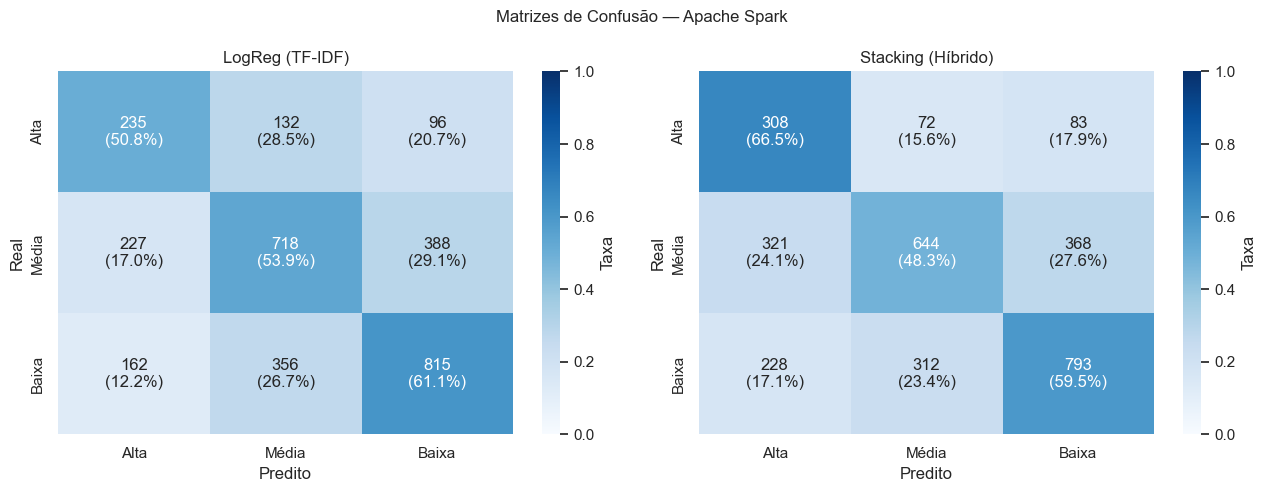

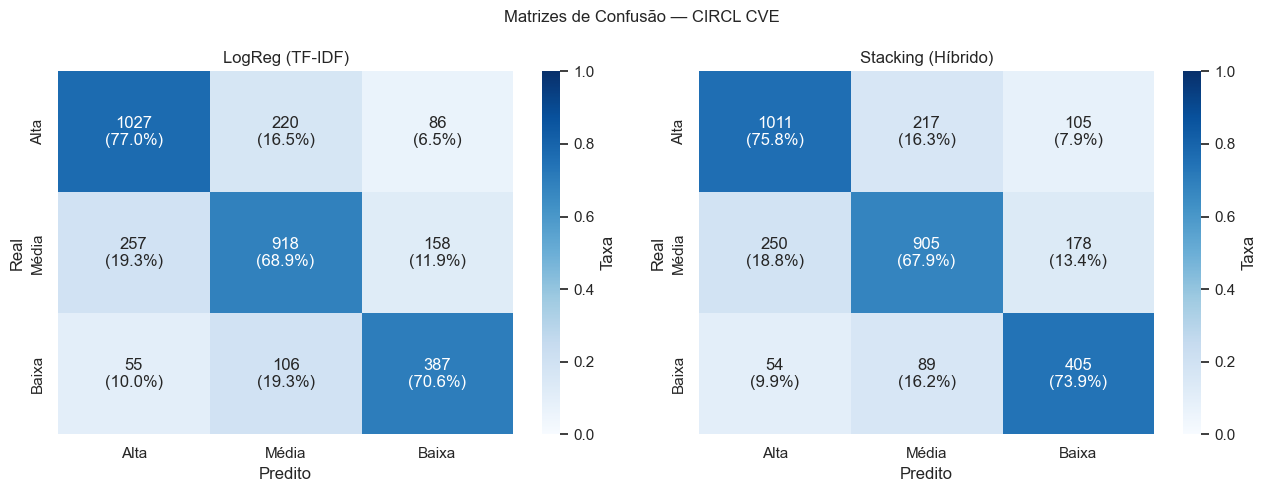

In [22]:
# ── Matrizes de confusão: melhor baseline vs Stacking ────────────────────────

def best_baseline(results):
    return max(results.items(), key=lambda kv: kv[1]['summary'].loc['mean','F1-macro'])


def plot_confusion_pair(res_base, nome_base, res_stack, dataset_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Matrizes de Confusão — {dataset_name}', fontsize=12)

    for ax, res, nome in [(axes[0], res_base, nome_base),
                          (axes[1], res_stack, 'Stacking (Híbrido)')]:
        cm      = confusion_matrix(res['y_true'], res['y_pred'], labels=CLASSES)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        annot   = [[f'{cm[i,j]}\n({cm_norm[i,j]:.1%})' for j in range(3)] for i in range(3)]
        sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
                    xticklabels=CLASSES, yticklabels=CLASSES,
                    vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Taxa'})
        ax.set_title(nome)
        ax.set_xlabel('Predito'); ax.set_ylabel('Real')

    plt.tight_layout()
    fname = f'confusion_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


nome_bst_s, res_bst_s = best_baseline(results_spark)
nome_bst_c, res_bst_c = best_baseline(results_circl)
print(f'Melhor baseline Spark: {nome_bst_s}')
print(f'Melhor baseline CIRCL: {nome_bst_c}')

plot_confusion_pair(res_bst_s, nome_bst_s, result_stack_spark, 'Apache Spark')
plot_confusion_pair(res_bst_c, nome_bst_c, result_stack_circl, 'CIRCL CVE')

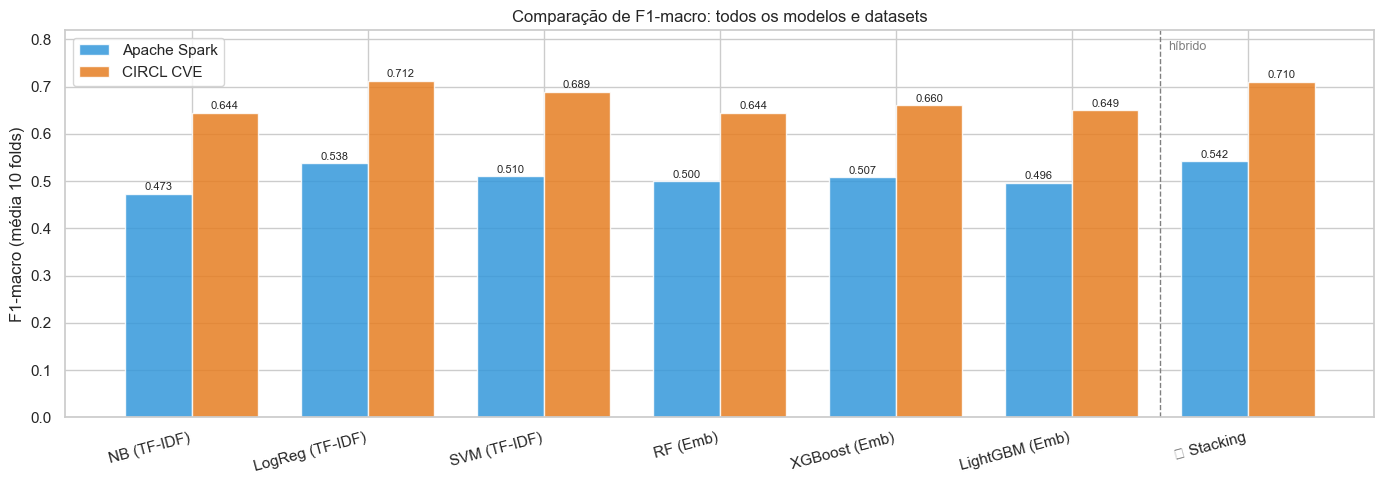

In [23]:
# ── Gráfico de barras comparativo: F1-macro por modelo e dataset ──────────────

def plot_f1_comparison(results_spark, results_circl, stack_s, stack_c):
    modelos = list(results_spark.keys()) + ['★ Stacking']
    f1_spark = [results_spark[n]['summary'].loc['mean','F1-macro'] for n in results_spark]
    f1_spark += [stack_s['summary'].loc['mean','F1-macro']]
    f1_circl = [results_circl[n]['summary'].loc['mean','F1-macro'] for n in results_circl]
    f1_circl += [stack_c['summary'].loc['mean','F1-macro']]

    x = np.arange(len(modelos)); w = 0.38
    fig, ax = plt.subplots(figsize=(14, 5))
    b1 = ax.bar(x - w/2, f1_spark, w, label='Apache Spark', color='#3498db', alpha=0.85)
    b2 = ax.bar(x + w/2, f1_circl, w, label='CIRCL CVE',    color='#e67e22', alpha=0.85)

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(modelos, rotation=15, ha='right')
    ax.set_ylabel('F1-macro (média 10 folds)')
    ax.set_title('Comparação de F1-macro: todos os modelos e datasets')
    ax.set_ylim(0, max(max(f1_spark), max(f1_circl)) * 1.15)
    ax.legend()
    ax.axvline(len(modelos) - 1.5, color='gray', linestyle='--', linewidth=1)
    ax.text(len(modelos) - 1.5 + 0.05, ax.get_ylim()[1]*0.95, 'híbrido',
            fontsize=9, color='gray')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'f1_comparacao_geral.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_f1_comparison(results_spark, results_circl, result_stack_spark, result_stack_circl)

---
## Seção 11 — Comparação Final: Teste de Wilcoxon

**H₀:** Stacking e melhor baseline têm desempenho equivalente  
**H₁:** Stacking tem desempenho diferente (bicaudal)

Usamos Wilcoxon signed-rank (não-paramétrico, pareado) porque com n=10 folds
não podemos verificar normalidade dos resíduos para o t-test.


=== Wilcoxon — Apache Spark ===
Stacking vs LogReg (TF-IDF) | métrica: F1-macro
  Stacking:  [0.553  0.5176 0.5556 0.5826 0.5796 0.4933 0.5793 0.5071 0.5115 0.5389]
  Baseline:  [0.5681 0.524  0.4924 0.5736 0.5665 0.5148 0.5457 0.5156 0.5193 0.5607]
  Diferença: [-0.0151 -0.0063  0.0631  0.009   0.0131 -0.0215  0.0336 -0.0085 -0.0078
 -0.0218]
  Stacking média:  0.5419 ± 0.0314
  Baseline média:  0.5381 ± 0.0269
  Melhora média:   +0.0038

  Wilcoxon: W=27.000, p=1.0000
  CONCLUSÃO: p ≥ 0.05 → sem evidência de diferença significativa.


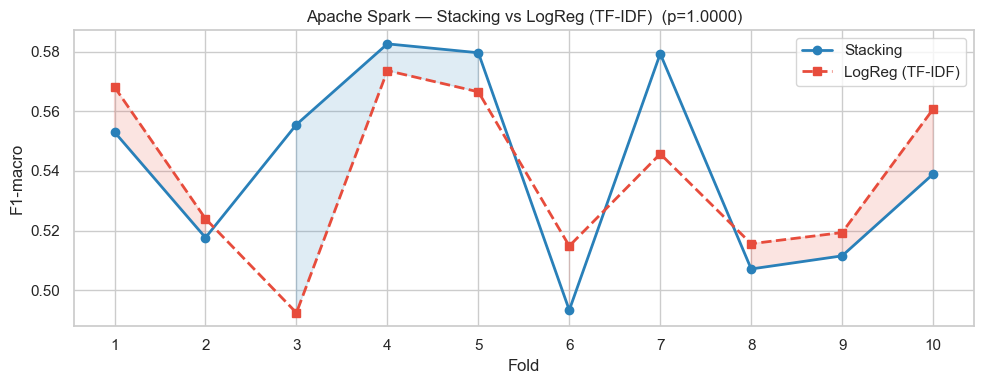


=== Wilcoxon — CIRCL CVE ===
Stacking vs LogReg (TF-IDF) | métrica: F1-macro
  Stacking:  [0.7548 0.6963 0.7487 0.7076 0.6884 0.7225 0.7277 0.6527 0.7391 0.6603]
  Baseline:  [0.7224 0.7185 0.7191 0.7047 0.7139 0.7245 0.7234 0.6602 0.7385 0.694 ]
  Diferença: [ 0.0324 -0.0223  0.0296  0.0029 -0.0255 -0.0021  0.0043 -0.0074  0.0005
 -0.0337]
  Stacking média:  0.7098 ± 0.0335
  Baseline média:  0.7119 ± 0.0206
  Melhora média:   -0.0021

  Wilcoxon: W=25.000, p=0.8457
  CONCLUSÃO: p ≥ 0.05 → sem evidência de diferença significativa.


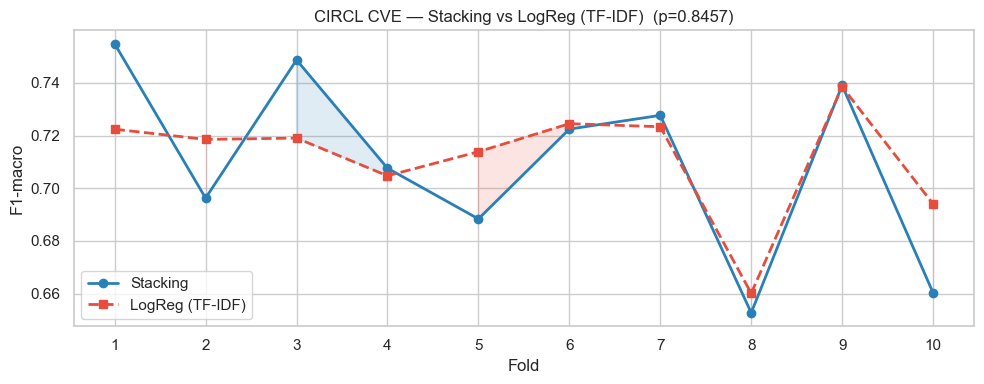

In [24]:
def teste_wilcoxon(res_stack, res_base, nome_base, dataset_name, metrica='F1-macro'):
    f1_st = res_stack['folds'][metrica].values
    f1_bs = res_base['folds'][metrica].values
    diff  = f1_st - f1_bs

    print(f'\n=== Wilcoxon — {dataset_name} ===')
    print(f'Stacking vs {nome_base} | métrica: {metrica}')
    print(f'  Stacking:  {f1_st.round(4)}')
    print(f'  Baseline:  {f1_bs.round(4)}')
    print(f'  Diferença: {diff.round(4)}')
    print(f'  Stacking média:  {f1_st.mean():.4f} ± {f1_st.std():.4f}')
    print(f'  Baseline média:  {f1_bs.mean():.4f} ± {f1_bs.std():.4f}')
    print(f'  Melhora média:   {diff.mean():+.4f}')

    if np.all(diff == 0):
        print('  AVISO: diferenças todas zero — Wilcoxon não aplicável.')
        return

    stat, p = wilcoxon(f1_st, f1_bs, alternative='two-sided')
    print(f'\n  Wilcoxon: W={stat:.3f}, p={p:.4f}')
    if p < 0.05:
        print(f'  CONCLUSÃO: p < 0.05 → diferença SIGNIFICATIVA')
        print(f'  Stacking é {"MELHOR" if diff.mean() > 0 else "PIOR"} que {nome_base}.')
    else:
        print(f'  CONCLUSÃO: p ≥ 0.05 → sem evidência de diferença significativa.')

    # Gráfico fold-a-fold
    fig, ax = plt.subplots(figsize=(10, 4))
    folds = range(1, len(f1_st) + 1)
    ax.plot(folds, f1_st, 'o-', label='Stacking', color='#2980b9', linewidth=2)
    ax.plot(folds, f1_bs, 's--', label=nome_base, color='#e74c3c', linewidth=2)
    ax.fill_between(folds, f1_st, f1_bs,
                    where=(f1_st >= f1_bs), alpha=0.15, color='#2980b9')
    ax.fill_between(folds, f1_st, f1_bs,
                    where=(f1_st < f1_bs), alpha=0.15, color='#e74c3c')
    ax.set_xticks(list(folds))
    ax.set_xlabel('Fold'); ax.set_ylabel(metrica)
    ax.set_title(f'{dataset_name} — Stacking vs {nome_base}  (p={p:.4f})')
    ax.legend()
    plt.tight_layout()
    fname = f'wilcoxon_{dataset_name.lower().replace(" ","_")}.png'
    plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()


teste_wilcoxon(result_stack_spark, res_bst_s, nome_bst_s, 'Apache Spark')
teste_wilcoxon(result_stack_circl, res_bst_c, nome_bst_c, 'CIRCL CVE')

---
## Seção 12 — Conclusão

### Decisões de design justificadas

| Decisão | Justificativa |
|---|---|
| F1-macro como métrica principal | Equânime entre classes; acurácia é enganosa com desbalanceamento |
| Pré-processamento mínimo | TF-IDF com IDF penaliza stopwords; embeddings precisam do contexto |
| SMOTE **dentro** do fold | Evita data leakage — bug clássico de trabalhos que aplicam SMOTE antes do split |
| Undersampling real-first | Preserva amostras reais da classe rara antes do SMOTE |
| Stacking com OOF | Evita leakage nas meta-features |
| 4 modelos base diversos | TF-IDF linear + embedding ensemble = complementaridade máxima |
| XGBoost + LightGBM | Cumpre requisito de modelos não-sklearn |
| Friedman + Nemenyi | Comparação robusta entre múltiplos modelos (Demšar, 2006) |
| Wilcoxon | Comparação pareada final não-paramétrica |
| Dois datasets | Avalia generalização além do domínio original de Lamkanfi |

### Limitações

1. **Mapeamento de rótulos:** prioridade Jira é subjetiva; CVSS pode ser revisado retroativamente
2. **Generalização limitada:** Spark é um único projeto open-source
3. **Custo computacional:** Stacking aninhado (10 × 5 folds × 4 modelos) requer muita CPU
4. **Folds não totalmente independentes:** Wilcoxon e Friedman podem superestimar significância

### Próximos passos

- Fine-tuning do Qwen3 nos dados de bug reports (representação específica do domínio)
- Integração de features estruturadas (componente, versão, histórico do reportador)
- Avaliação cross-project: treinar no Spark, testar no CIRCL e vice-versa
- Deploy em sistema de triagem automática com feedback loop